In [1]:
# 1. feature selection, model training and feature reduction have been included as functions and called at each level
# 2. SHAP analysis functions currectly works for serogroup classification only (pan gene presence absence dataset)
# 3. SHAP function is defined separately for serotype classification
# 4. The feature labels have to be mapped to the right annotation (for serogroup - thinking of blast (for all hypothetical genes))
     ## for serotype.. it has to be mapped based on the tsv files generated (currently working on this)
# 5. The model performance decreased especially for serotype classification (less sample size). Overfitting was there
# 6. Data leakage was test through shuffling and training of logistic regression (both levels, it was less than 0.5)

# 7. For the serogroup level, the model performance was good and there was a linear separation.
###. For the serotype level,predicted probabilities were low and even if pseudo labeling 
###. and semisupervised methods were tried, it does not improve the performance of the model

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from glob import glob
import os

# test train split
from sklearn.model_selection import train_test_split

# feature reduction
from boruta import BorutaPy
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import GridSearchCV
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# Model comparison and evaluation
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.model_selection import LeaveOneOut, cross_val_predict

from collections import Counter
import textwrap
import re
from Bio import SeqIO
import joblib
import requests
from urllib.parse import quote
from sklearn.utils import shuffle
import random
import subprocess

import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec

/home/dell/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Defining functions

## Feature selection

In [184]:
def lasso_stability_selection(X_train, y_train,n_runs=10,Cs=[1e-4, 1e-3, 1e-2, 1e-1, 1],
                              cv=10,freq_threshold=0.7,random_state=42):

    # Standardize all features to ensure they are on the same scale before LASSO regularization
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)   # scaled X_train

    # storing features selected in each run
    selected_runs = []
    
    # Repeating LASSO feature selection 
    for i in range(n_runs):

        # L1 regularisaed logistic regression with cv 
        # identifies optimal c vales and less imp features are shrinked to 0
        lasso = LogisticRegressionCV(penalty='l1',solver='liblinear',Cs=Cs,cv=cv,  # CV = 10 folds
                                     scoring='roc_auc',class_weight='balanced',random_state=random_state + i,max_iter=1000)

        # model training of the scaled training data
        lasso.fit(X_scaled, y_train) 
        
        coef = lasso.coef_[0]
        lasso_mask = coef != 0  # non zero coefficients

        selected_features = X_train.columns[lasso_mask]  # filtering 
        selected_runs.extend(selected_features)  # features from each run is stored

    feature_counts = Counter(selected_runs)  # number of rns each feature got selected 
    feature_freq = pd.DataFrame.from_dict(feature_counts, orient="index", columns=["count"])
    feature_freq["frequency"] = feature_freq["count"] / n_runs # proportion of runs in which each feature was selected
    feature_freq = feature_freq.sort_values("frequency", ascending=False)

    stable_features = feature_freq[feature_freq["frequency"] >= freq_threshold].index   # threshold 70%

    print("Stable LASSO features:", len(stable_features))  

    return stable_features, feature_freq

In [185]:
print(cv)  # verified - stratifiedkfold with shuffling is used

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)


In [194]:
def boruta_stability_selection(X_train, y_train,n_runs=10,perc=85,
                               max_iter=200,freq_threshold=0.7,random_state=42):

    selected_runs = []
    
    # repeating the selection for 10 times
    for i in range(n_runs):
        # Random Forest model used by Boruta to calculate feature importance
        rf = RandomForestClassifier(n_estimators=1000,class_weight="balanced",random_state=random_state + i,n_jobs=-1)
        # comaparing original with shadow features and retaining the ones that are consistently important
        boruta_selector = BorutaPy(rf,n_estimators="auto",perc=perc,max_iter=max_iter,random_state=random_state + i)
        boruta_selector.fit(X_train.values, y_train.values)
        boruta_mask = boruta_selector.support_
        
        boruta_features = X_train.columns[boruta_mask]
        selected_runs.extend(boruta_features)

    feature_counts = Counter(selected_runs) # number of runs each feature got selected 
    feature_freq = pd.DataFrame.from_dict(feature_counts, orient="index", columns=["count"])
    feature_freq["frequency"] = feature_freq["count"] / n_runs # proportion of runs in which each feature was selected
    feature_freq = feature_freq.sort_values("frequency", ascending=False)

    selected_features = feature_freq[feature_freq["frequency"] >= freq_threshold].index  # threshold 70%
    boruta_mask = X_train.columns.isin(selected_features) # stable boruta features

    X_train_boruta = X_train.loc[:, boruta_mask] # filtering (train set)

    print("Selected Boruta features:", X_train_boruta.shape[1])
    return X_train_boruta, selected_features, feature_freq

In [195]:
def combined_feature_selection(X_train, y_train, X_test,lasso_params,boruta_params):

    lasso_features, lasso_freq = lasso_stability_selection(X_train, y_train, **lasso_params)  # LASSO features 
    X_train_boruta, boruta_features, boruta_freq = boruta_stability_selection(X_train, y_train, **boruta_params) # Bourta features

    X_train_lasso = X_train.loc[:, lasso_features]  # train set - lasso features
    X_test_lasso = X_test.loc[:, lasso_features]  # test set - lasso features

    scaler = StandardScaler()
    X_train_lasso = scaler.fit_transform(X_train_lasso)  # scaling for lasso
    X_test_lasso  = scaler.transform(X_test_lasso)  # scaling for lasso

    X_test_boruta = X_test.loc[:, X_train_boruta.columns] # boruta features (test set) (train set has been filtered in the previous function)
    lasso_set = set(lasso_features)
    boruta_set = set(boruta_features)

    common_features = sorted(list(lasso_set & boruta_set))
    
    print("LASSO features:", len(lasso_set))
    print("Boruta features:", len(boruta_set))
    print("Intersection:", len(common_features))

    if len(common_features) == 0:
        raise ValueError("No overlapping features between LASSO and Boruta.")

    X_train_intersection = X_train.loc[:, common_features]
    X_test_intersection = X_test.loc[:, X_train_intersection.columns]

    return {
        "lasso": (X_train_lasso, X_test_lasso, lasso_features, lasso_freq),
        "boruta": (X_train_boruta, X_test_boruta, boruta_features, boruta_freq),
        "intersection": (X_train_intersection, X_test_intersection, common_features)
    }

## Evaluation of selected features

In [204]:
# comparing the lasso, boruta and the intersection feature set with log_reg and rf
# log_reg and rf is mainly chosen as the representative linear and tree models 

# the performance metrics are compared withe ach other to select the best feature set

In [205]:
def cv_logistic(X, y):

    model = LogisticRegression(max_iter=3000, random_state=42)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # 10 fold CV
    if hasattr(X, "values"):
        X = X.values   # converts to numpy for consistency

    scores = cross_val_score(model,X,y,cv=cv,scoring="roc_auc",n_jobs=-1)
    return scores

In [206]:
def cv_rf(X, y):

    model = RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    if hasattr(X, "values"):  
        X = X.values  # converts to numpy for consistency

    scores = cross_val_score(model,X,y,cv=cv,scoring="roc_auc",n_jobs=-1)
    return scores

In [207]:
def compute_cv_scores(X_train_lasso, X_train_boruta, X_train_inter, y_train):

    rf_scores = cv_rf(X_train_boruta, y_train)    # rf + boruta
    log_scores = cv_logistic(X_train_lasso, y_train) # log_reg + lasso
    log_inter_scores = cv_logistic(X_train_inter, y_train)  # log_reg + inetrsection set
    rf_inter_scores = cv_rf(X_train_inter, y_train) # rf + intersection set 
    rf_lasso_scores = cv_rf(X_train_lasso, y_train) # rf + lasso

    df_scores = pd.DataFrame({   # combining all cv scores
        "ROC_AUC": np.concatenate([rf_lasso_scores, rf_scores, log_scores, log_inter_scores, rf_inter_scores]),
        "Model": (["RF + LASSO"] * len(rf_lasso_scores) +   
                  ["RF + Boruta"] * len(rf_scores) +
                  ["Logistic + LASSO"] * len(log_scores) +
                  ["Logistic + intersection"] * len(log_inter_scores) +
                  ["RF + intersection"] * len(rf_inter_scores))
    })

    # model, mean ROC and std_dev
    summary_stats = (df_scores.groupby("Model")["ROC_AUC"].agg(mean_ROC_AUC="mean", sd_ROC_AUC="std").reset_index())

    
    def get_train_metrics(model, X, y):
        model.fit(X, y)
        y_pred = model.predict(X)
        return accuracy_score(y, y_pred), f1_score(y, y_pred)  # to obtain accuracy and fi score
        
    rf = RandomForestClassifier(random_state=42)  # models
    log = LogisticRegression(max_iter=1000)
        
    metrics = []
    acc, f1 = get_train_metrics(rf, X_train_lasso, y_train)  
    metrics.append(["RF + LASSO", acc, f1])
        
    acc, f1 = get_train_metrics(rf, X_train_boruta, y_train)
    metrics.append(["RF + Boruta", acc, f1])
        
    acc, f1 = get_train_metrics(log, X_train_lasso, y_train)
    metrics.append(["Logistic + LASSO", acc, f1])
        
    acc, f1 = get_train_metrics(log, X_train_inter, y_train)
    metrics.append(["Logistic + intersection", acc, f1])
        
    acc, f1 = get_train_metrics(rf, X_train_inter, y_train)
    metrics.append(["RF + intersection", acc, f1])
        
    train_metrics_df = pd.DataFrame(metrics, columns=["Model", "Train Accuracy", "Train F1"])

    return df_scores, summary_stats, train_metrics_df

In [208]:
def plot_cv_results(df_scores, save_path=None):

    plt.figure(figsize=(10, 8))

    sns.violinplot(data=df_scores,x="Model",y="ROC_AUC",hue="Model",
                   inner=None,palette=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#FAE251"],
                   cut=0,legend=False)

    sns.boxplot(data=df_scores,x="Model",y="ROC_AUC",width=0.2,showcaps=True,
        boxprops={"facecolor": "white", "zorder": 3},showfliers=False,whiskerprops={"linewidth": 1.5})

    sns.stripplot(data=df_scores,x="Model",y="ROC_AUC",color="black",size=6,jitter=True,alpha=0.7)  # plotting ROC values for all 10 folds
    plt.ylabel("ROC-AUC (10-fold CV)", fontsize=12)
    plt.xlabel("")
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

## Model training before CV and tuning

In [209]:
# training the models first without cv and tuning for comparison 

In [210]:
def train_and_evaluate_basic(model_name,model,X_train, y_train,X_test, y_test):
    
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)  # train set
    y_test_pred  = model.predict(X_test)  # test set

    report = classification_report(y_test, y_test_pred, output_dict=True)  # classification report for test set

    results = {"Model": model_name,
               "Train Accuracy": accuracy_score(y_train, y_train_pred),
               "Test Accuracy": accuracy_score(y_test, y_test_pred),
               "Precision (macro)": report["macro avg"]["precision"],
               "Recall (macro)": report["macro avg"]["recall"],
               "F1-score (macro)": report["macro avg"]["f1-score"],
               "ROC AUC": (roc_auc_score(
                   y_test, model.predict_proba(X_test)[:, 1]) if hasattr(model, "predict_proba") else np.nan)}

    return results

In [211]:
# model training and evaluation (before hyperparameter tuning)
models_bcv = [
    ("Logistic Regression", LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")),
    ("Decision Tree", DecisionTreeClassifier(random_state=42, class_weight="balanced")),
    ("SVC", SVC(probability=True, random_state=42, class_weight="balanced")),
    ("KNN", KNeighborsClassifier()),
    ("Naive Bayes", GaussianNB()),
    ("Random Forest", RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")),
    ("Extra Trees", ExtraTreesClassifier(random_state=42, n_jobs=-1, class_weight="balanced")),
    ("XGBoost", xgb.XGBClassifier(eval_metric="logloss", random_state=42)),
]

## Model training - CV and tuning

In [212]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)  # cv 10 folds
def train_and_evaluate_cv(model_name,model,param_grid,X_train, y_train,X_test, y_test,cv,scoring="f1_macro"):

    grid = GridSearchCV(estimator=model,param_grid=param_grid,cv=cv,scoring=scoring,n_jobs=-1,refit=True)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_train_pred = best_model.predict(X_train)  # train set
    y_test_pred  = best_model.predict(X_test) # test set

    report = classification_report(y_test, y_test_pred, output_dict=True)  # classification report for the test

    results = {"Model": model_name,
               "Best Params": grid.best_params_,   # best hyper parameters
               "CV Score": grid.best_score_,
               "Train Accuracy": accuracy_score(y_train, y_train_pred),
               "Test Accuracy": accuracy_score(y_test, y_test_pred),
               "Precision (macro)": report["macro avg"]["precision"],
               "Recall (macro)": report["macro avg"]["recall"],
               "F1-score (macro)": report["macro avg"]["f1-score"],
               "ROC AUC": (roc_auc_score(
                           y_test, best_model.predict_proba(X_test)[:, 1])if hasattr(best_model, "predict_proba")else np.nan),
               "Best Estimator": best_model}

    return results

In [213]:
# hyper parameter tuning 
logreg = LogisticRegression(max_iter=3000, class_weight="balanced")
logreg_params = {"C": [0.01, 0.1, 1, 10],"penalty": ["l2"],"solver": ["lbfgs"]}

svc = SVC(probability=True, random_state=42, class_weight="balanced")
svc_params = {"C": [0.1, 1, 10],"kernel": ["linear", "rbf"],"gamma": ["scale", "auto"]}

knn = KNeighborsClassifier()
knn_params = {"n_neighbors": [3, 5, 7, 11],"weights": ["uniform", "distance"]}

nb = GaussianNB()
nb_params = {}

rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")
rf_params = {"n_estimators": [100, 300],"max_depth": [None, 5, 10],"min_samples_split": [2, 5],"max_features": ["sqrt"]}

et = ExtraTreesClassifier(random_state=42, n_jobs=-1, class_weight="balanced")
et_params = {"n_estimators": [100, 300],"max_depth": [None, 5, 10],"min_samples_split": [2, 5],"max_features": ["sqrt"]}

xgb_model = xgb.XGBClassifier(eval_metric="logloss", random_state=42,n_jobs=1)
xgb_params = {"n_estimators": [100, 300],"max_depth": [3, 5],"learning_rate": [0.01, 0.1],
              "subsample": [0.8, 1.0],"colsample_bytree": [0.8, 1.0]}

dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dt_params = {"max_depth": [None, 3, 5, 7, 10],"min_samples_split": [2, 5, 10],
             "min_samples_leaf": [1, 2, 5],"criterion": ["gini", "entropy"]}



In [214]:
# model training
models_cv = [("Logistic Regression", logreg, logreg_params),
             ("Decision Tree", dt, dt_params),
             ("SVC", svc, svc_params),
             ("KNN", knn, knn_params),
             ("Naive Bayes", nb, nb_params),
             ("Random Forest", rf, rf_params),
             ("Extra Trees", et, et_params),
             ("XGBoost", xgb_model, xgb_params)]

## Feature importance - SHAP analysis 

In [216]:
# feature importance for the best model with feature set used for training

In [217]:
gpa_path = "/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/1_pan_data/panaroo_out/gene_presence_absence.csv"
fasta_file = "/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/1_pan_data/panaroo_out/pan_genome_reference.fa"
blast_db = "/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/3_supervised_ml/swissprot_db/swissprot"

In [218]:
oagc_df = pd.read_csv(
    "/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/3_supervised_ml/2_serotype_files/oagc/oagc_genes.tsv",
    sep="\t",header=None)

oagc_features = oagc_df[1].astype(str).str.strip().tolist()

In [219]:
def build_label_map(gpa_path):
    gpa = pd.read_csv(gpa_path, low_memory=False,
                      usecols=['Gene', 'Annotation', 'Non-unique Gene name'])  # required columns from presence_absence.csv (Panaroo result)

    def get_best_label(row):
        gene_id = row["Gene"]  # gene cluster id

        if pd.isna(row["Annotation"]):   # missing annotation
            return f"hypothetical protein ({gene_id})"

        ann = row["Annotation"].strip()

        if ann.lower() == "hypothetical protein":   # explicitly hypothetical protein
            return f"hypothetical protein ({gene_id})"

        parts = [p.strip() for p in ann.split(";")]  # multiple annotations
        parts = [p for p in parts if p.lower() != "hypothetical protein"]  # remove useless ones

        if not parts:   # no meaningful annotation left
            return f"hypothetical protein ({gene_id})"

        for p in parts:  # keyword prioritization
            if any(word in p.lower() for word in ["transposase", "toxin", "protein", "enzyme"]):
                return p

        return parts[0]  # first annotation (*;)

    gpa["label"] = gpa.apply(get_best_label, axis=1)   # get_best_label_function (to get the appropriate annonotation)

    gpa["label"] = gpa["label"].fillna("hypothetical protein (" + gpa["Gene"] + ")")  # NA values

    return dict(zip(gpa["Gene"], gpa["label"]))   # dict - gene and annotation

In [220]:
def run_blast_for_features(feature_list, fasta_file, blast_db, out_file):

    temp_fasta = "temp_query.fasta"  # fasta file for sequences with the annotation: 'hypothetical protein'
    feature_set = set(feature_list)  # list to set converstion

    count = 0
    with open(temp_fasta, "w") as out_f:
        for record in SeqIO.parse(fasta_file, "fasta"):   # looping through all sequences in pan_ref.fa
            if record.id in feature_set:  # if the sequence id is a hypothetical gene
                SeqIO.write(record, out_f, "fasta")   # adding those fasta sequences to temporary fasta file
                count += 1    # final loop will have total no. of sequences 

    if count == 0:  # if no sequneces added
        print("No matching sequences found for BLAST")
        return {}

    os.environ["BLASTDB"] = os.path.dirname(blast_db)  # blastdb (swissprot)

    cmd = ["blastx",
           "-query", temp_fasta,   # temporary fasta file with 'hypothetical protein' sequences (nt)
           "-db", os.path.basename(blast_db),  # swissprot database
           "-out", out_file,  # output file
           "-evalue", "1e-5",  # evalue threshold
           "-outfmt", "6 qseqid sseqid bitscore stitle"]  # blast columns

    result = subprocess.run(cmd,stdout=subprocess.PIPE,stderr=subprocess.PIPE,text=True)

    if result.stderr:
        print(result.stderr)  # errors from blast command (if failed)

    if not os.path.exists(out_file) or os.path.getsize(out_file) == 0:  # if blast file is empty
        print("BLAST output is empty")  # no hits
        return {}

    blast_df = pd.read_csv(out_file, sep="\t", header=None)  # output file

    blast_df = blast_df.iloc[:, :4]
    blast_df.columns = ["qseqid", "sseqid", "bitscore", "stitle"]  # columns

    best_hits = (blast_df.sort_values("bitscore", ascending=False).drop_duplicates("qseqid"))
    return dict(zip(best_hits["qseqid"], best_hits["stitle"]))

In [221]:
def plot_shap_summary(model, X, features, label_map,raw_features = None,
                      level="serogroup",   # default: serogroup
                      fasta_file=None, blast_db=None, 
                      max_display=15,sample_size=100,save_path=None):

    valid_features = [f for f in features if f in X.columns]  # only selected features for ML are considered
    missing_features = [f for f in features if f not in X.columns]

    X_shap = X[valid_features].copy()  # selected features 
    features = valid_features

    labels = []   # empty list to store feature labels
    for f in features:   
        if f in label_map:
            label = label_map[f]  # if annotation is present then that is used (build_label_map function has to be called before this)
        else:
            if level == "serogroup":
                label = f"hypothetical protein ({f})"   # for level 1 classification
            else:
                label = f  # level 2 classification
        labels.append(label)

    hypo_features = [
        f for f, l in zip(features, labels)
        if "hypothetical protein" in l.lower()   # features annotated as 'hypothetical protein'
    ]

    if fasta_file and blast_db and len(hypo_features) > 0:  # fasta_file, blast_db and number og genes annotated as hypothetical protein check
        print(f"Running BLAST for {len(hypo_features)} hypothetical genes...")  
        blast_map = run_blast_for_features(hypo_features,fasta_file,blast_db,"blast_results.tsv")   # blast function

        for gene in blast_map:
            old_label = label_map.get(gene, f"hypothetical protein ({gene})")  # previous label
            raw_label = blast_map[gene] # blast annotation 

            if "RecName:" in raw_label:  # swissprot format has 'RecName'
                clean_label = raw_label.split("RecName: Full=")[-1].split(";")[0]  # label cleaning
            else:
                clean_label = raw_label.split(";")[0]

            clean_label = clean_label.split("[")[0].strip()  # organism name

            print(f"{gene}")  # gene name
            print(f"  BEFORE: {old_label}")  # before blast
            print(f"  AFTER : {clean_label}\n") # after blast

            label_map[gene] = clean_label  # updating label_map dictionary

        labels = []
        for f in features:
            if f in label_map:
                label = label_map[f]
            else:
                if level == "serogroup":
                    label = f"hypothetical protein ({f})"
                else:
                    label = f
            labels.append(label)  # repeating the label list append step to include balst annotations

    final_labels = []

    for f, l in zip(features, labels):
        # wbeT features 
        if f == "frag_len":
            l = "Nucleotide sequence length (wbeT)"
        elif f == "aa_length":
            l = "Amino acid sequence length (wbeT)"
        elif f == "has_hit":
            l = "Presence of wbeT"
        elif f == "internal_stop_codons":
            l = "Internal stop codons (wbeT)"

        # normalising the virulence genes to their abbreviations
        elif "Toxin coregulated pilus biosynthesis protein R" in l:
            l = "tcpR"
            
        # putative instead of uncharacterised
        elif "Uncharacterized protein" in l:
            l = l.replace("Uncharacterized protein", "Putative protein")

        #print(f"{f}  --->  {l}")
        final_labels.append(l)

    X_shap.columns = ["\n".join(textwrap.wrap(str(l), 25))for l in final_labels]  

    highlight_labels = set() 
    if raw_features is not None:  # OAGC genes
        raw_set = set([str(x).strip() for x in raw_features])
        for f, l in zip(features, final_labels):   
            if str(f).strip() in raw_set:   # match with oagc genes and ML features
                wrapped = "\n".join(textwrap.wrap(str(l), 25))
                highlight_labels.add(wrapped)
                #print(f"matched oagc features: {f} ---> {l}")

    model_name = type(model).__name__  # model type

    if model_name in ["RandomForestClassifier", "ExtraTreesClassifier","DecisionTreeClassifier", "XGBClassifier"]:   # tree model
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_shap)

    elif model_name == "LogisticRegression":  # logistic regression
        explainer = shap.LinearExplainer(model, X_shap)
        shap_vals = explainer.shap_values(X_shap)

    else:  # other models
        background = shap.sample(X_shap, sample_size)
        if hasattr(model, "predict_proba"):
            explainer = shap.KernelExplainer(model.predict_proba, background)
        else:
            explainer = shap.KernelExplainer(model.predict, background)
        shap_vals = explainer.shap_values(X_shap)

    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]  # for 2D array output [class0_valuues, class1_values]

    elif isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 1] # for (samples, features, classes) kind of output

    shap.summary_plot(shap_vals,X_shap,max_display=max_display,cmap="coolwarm",show=False)

    ax = plt.gca()
    ax.tick_params(axis='y', labelsize=9)

    for label in ax.get_yticklabels():
        label.set_fontweight("bold")
        
        if raw_features is not None:
            label_text = label.get_text().replace("\n", " ").strip()

            for hl in highlight_labels:
                if label_text == hl.replace("\n", " ").strip():
                    label.set_color("#1f77b4")  # highlighting oagc genes in green       
                    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        
    plt.tight_layout()
    plt.show()

# Serogroup classification

## Dataset preparation

### serotype info - labels

In [20]:
metadata = pd.read_csv("/media/dell/My Passport/vc_files_v_final/1_data_curation/metadata_filtered.csv")
serotype_info = metadata[['Sample_ID','serogroup_serotype']]
serotype_info

,Sample_ID,serogroup_serotype
0,VC_0001,non_O1
1,VC_0002,non_O1
2,VC_0003,non_O1
3,VC_0004,non_O1
4,VC_0005,non_O1
...,...,...
1861,VC_1862,non_O1
1862,VC_1863,non_O1
1863,VC_1864,non_O1
1864,VC_1865,non_O1


### pan data - features

In [21]:
pan_data = pd.read_csv('/media/dell/My Passport/vc_files_v_final/3_supervised_learning/1_serogroup/gene_presence_absence.Rtab',sep = '\t', index_col=0)
pan_data = pan_data.T
pan_data = pan_data.reset_index()
pan_data = pan_data.rename(columns = {'index':'Sample_ID'})
pan_data

Gene,Sample_ID,zntA_1~~~zntA~~~zntA_2,ppc~~~ppc_2~~~ppc_1,uvrC~~~uvrC_1~~~uvrC_2,lptC~~~lptC_2~~~lptC_1,kdsD~~~kdsD_2~~~kdsD_1,mgtE,speA_1~~~speA_2~~~speA,rng~~~rng_1~~~rng_2,ppiA,...,group_61,group_56,rrrD,group_49,group_44,group_43,group_26,group_21,group_14,group_5
0,VC_0001,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,VC_0002,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,VC_0003,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,VC_0004,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,VC_0005,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1861,VC_1862,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1862,VC_1863,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1863,VC_1864,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1864,VC_1865,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


### Features + labels

In [22]:
clf1_dataset = pd.merge(serotype_info, pan_data, on="Sample_ID")
clf1_dataset.set_index('Sample_ID')
clf1_dataset['serogroup_serotype'].value_counts()

serogroup_serotype
unkwn           1455
non_O1           129
O1_Ogawa         106
O1_Inaba          88
O1_unkwn          87
O1_Hikoshima       1
Name: count, dtype: int64

In [23]:
clf1_dataset = clf1_dataset.copy()
#clf_1_dataset = clf1_dataset[(clf1_dataset['serogroup_serotype'] != 'O1_Hikoshima')]
o1_altered = {"O1_unkwn": "O1", "O1_Ogawa": "O1", "O1_Inaba": "O1",'O1_Hikoshima':'O1','non_O1':'non_O1','unkwn':'unkwn'}
clf1_dataset["serogroup"] = (clf1_dataset["serogroup_serotype"].replace(o1_altered))

In [24]:
clf1_dataset['serogroup'].value_counts()

serogroup
unkwn     1455
O1         282
non_O1     129
Name: count, dtype: int64

### label encoding

In [25]:
clf1_labels = {'O1':1,'non_O1':0,'unkwn':-1}
clf1_dataset["serogroup_labels"] = (clf1_dataset["serogroup"].map(clf1_labels).astype("Int64"))
clf1_dataset['serogroup_labels'].value_counts()

serogroup_labels
-1    1455
1      282
0      129
Name: count, dtype: Int64

In [28]:
clf1_dataset.shape

(1866, 24991)

In [29]:
clf1_dataset.columns

Index(['Sample_ID', 'serogroup_serotype', 'zntA_1~~~zntA~~~zntA_2',
       'ppc~~~ppc_2~~~ppc_1', 'uvrC~~~uvrC_1~~~uvrC_2',
       'lptC~~~lptC_2~~~lptC_1', 'kdsD~~~kdsD_2~~~kdsD_1', 'mgtE',
       'speA_1~~~speA_2~~~speA', 'rng~~~rng_1~~~rng_2',
       ...
       'rrrD', 'group_49', 'group_44', 'group_43', 'group_26', 'group_21',
       'group_14', 'group_5', 'serogroup', 'serogroup_labels'],
      dtype='str', length=24991)

In [88]:
# merged the serotype info from the metadata with the pan gene presence absence matrix from panaroo

### Saving the dataset

In [26]:
clf1_dataset.to_csv('/media/dell/My Passport/vc_files_v_final/3_supervised_learning/1_serogroup/1_clf1_dataset.csv')

## Supervised ML serogroup classification

### dataset

In [30]:
dataset = pd.read_csv('/media/dell/My Passport/vc_files_v_final/3_supervised_learning/1_serogroup/1_clf1_dataset.csv')
dataset = dataset.set_index('Sample_ID')
dataset = dataset.drop(columns =['Unnamed: 0'])
dataset['serogroup_labels'].value_counts()

serogroup_labels
-1    1455
 1     282
 0     129
Name: count, dtype: int64

### feature label split

In [31]:
X = dataset.drop(['serogroup_serotype','serogroup','serogroup_labels'], axis=1)
y = dataset['serogroup_labels']

### labeled unlabeled split

In [32]:
X_unlabeled = X[y == -1]
X_labeled = X[y != -1]
y_labeled = y[y!= -1]

### test validation split

In [33]:
X_train, X_val, y_train, y_val = train_test_split(X_labeled,y_labeled,test_size = 0.2, stratify = y_labeled, random_state = 42)

In [34]:
print(X_train.shape)
print(X_val.shape)

print(set(X_train.columns) == set(X_val.columns))
print(len(set(X_train.index) & set(X_val.index)))

(328, 24987)
(83, 24987)
True
0


### Feature selection

In [35]:
results = combined_feature_selection(X_train, y_train, X_val,lasso_params={},boruta_params={})
X_train_lasso, X_val_lasso, lasso_features, lasso_freq = results["lasso"]
X_train_boruta, X_val_boruta, boruta_features, boruta_freq = results["boruta"]
X_train_intersection, X_val_intersection, common_features = results["intersection"]

Stable LASSO features: 103
Selected Boruta features: 1315
LASSO features: 103
Boruta features: 1315
Intersection: 90


In [36]:
df_scores, summary_stats,train_metrics_df = compute_cv_scores(X_train_lasso,X_train_boruta,X_train_intersection,y_train)
summary_stats

,Model,mean_ROC_AUC,sd_ROC_AUC
0,Logistic + LASSO,0.991272,0.015067
1,Logistic + intersection,0.996094,0.006088
2,RF + Boruta,0.988408,0.020496
3,RF + LASSO,0.995620,0.008961
4,RF + intersection,0.994380,0.010128


In [37]:
train_metrics_df

,Model,Train Accuracy,Train F1
0,RF + LASSO,1.000000,1.000000
1,RF + Boruta,1.000000,1.000000
2,Logistic + LASSO,1.000000,1.000000
3,Logistic + intersection,0.996951,0.997783
4,RF + intersection,1.000000,1.000000


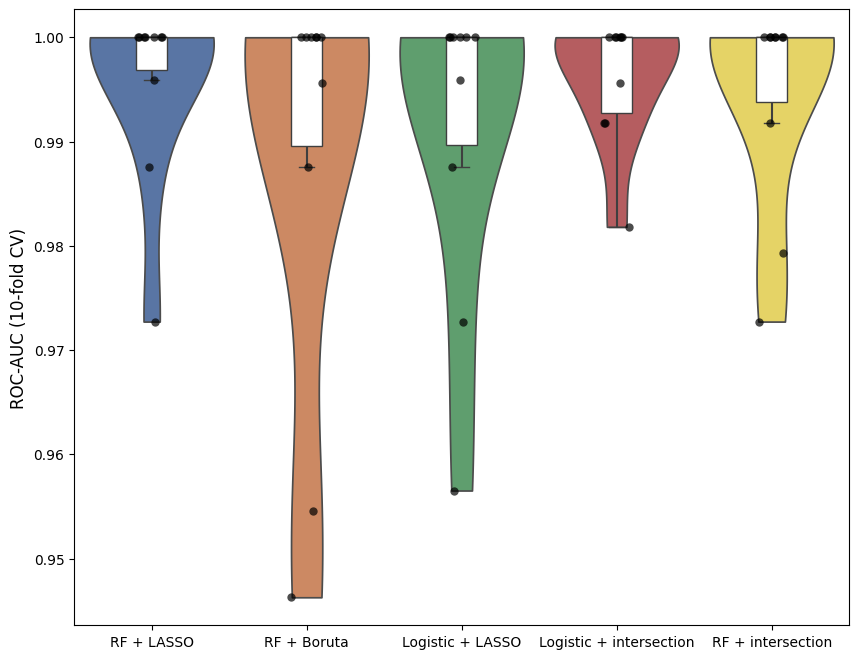

In [89]:
plot_cv_results(df_scores, save_path='/media/dell/My Passport/vc_files_v_final/plots/1_sg_class_ml.tif')

In [90]:
# intersection set was chosen for further training since it showed consistant performance
# RF -> performs well with intersection set (stable performance) 
# Log_reg -> best with intersection set (higher ROC AUC and lower standard deviation)

### Multicollinearity 

In [40]:
X_train_inter = X_train_intersection.reindex(sorted(X_train_intersection.columns), axis=1)   # alphabetical sortimg is done
X_val_inter   = X_val_intersection.reindex(sorted(X_val_intersection.columns), axis=1)   # same features are retained for every run

corr_matrix = X_train_inter.corr(method="spearman").abs()
#corr_matrix

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  #  only upper triangle to avoid duplicate correlation

to_drop = []
for col in upper.columns:
    if any(upper[col] > 0.97):
        to_drop.append(col)    # highly correlated features (> 0.97)

print("Number of correlated features:", len(to_drop))  # total features that are to be dropped

X_train_inter = X_train_inter.drop(columns=to_drop)   # filtering in train set
X_val_inter   = X_val_inter.drop(columns=[c for c in to_drop if c in X_val_inter.columns])   # filtering for validation set

print("Final feature count:", X_train_inter.shape[1])  # final feature count

Number of correlated features: 63
Final feature count: 27


In [41]:
pairs_df = (upper.stack().reset_index())
pairs_df.columns = ["Feature1", "Feature2", "Correlation"]

pairs_df = pairs_df[pairs_df["Correlation"] > 0.97]
pairs_df
pairs_df.to_csv("/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/3_supervised_ml/1_serogroup_files/6_correlated_features.csv", index=False)

In [42]:
corr_matrix['group_4008'][corr_matrix['group_4008'] > 0.90]  

group_3831                           0.943431
group_4008                           1.000000
group_4795                           0.972231
group_5060                           1.000000
group_5309                           0.972231
mak                                  0.928865
manA_2~~~manA_3~~~manA_1~~~manA_4    0.928865
manC1~~~rfbM                         0.936401
ppsB~~~menE_3~~~sauT~~~lcfB          1.000000
rfbE_2~~~rfbE                        1.000000
vioB                                 1.000000
Name: group_4008, dtype: float64

In [43]:
corr_matrix['group_4795'][corr_matrix['group_4795'] > 0.90]  

group_3831                           0.917233
group_4008                           0.972231
group_4795                           1.000000
group_5060                           0.972231
group_5309                           0.972123
mak                                  0.902816
manA_2~~~manA_3~~~manA_1~~~manA_4    0.902816
manC1~~~rfbM                         0.910398
ppsB~~~menE_3~~~sauT~~~lcfB          0.972231
rfbE_2~~~rfbE                        0.972231
vioB                                 0.972231
Name: group_4795, dtype: float64

### Model training before CV and tuning

In [44]:
results = []

for name, model in models_bcv:
    res = train_and_evaluate_basic(name, model,X_train_inter, y_train,X_val_inter, y_val)
    results.append(res)

In [47]:
df_bcv = pd.DataFrame(results)
df_bcv = df_bcv.round(3)
df_bcv = df_bcv.sort_values(by=["F1-score (macro)", "ROC AUC"], ascending=False)
df_bcv.to_csv('/media/dell/My Passport/vc_files_v_final/tables/1_sg_class_metrics_beforecv.csv')
df_bcv

,Model,Train Accuracy,Test Accuracy,Precision (macro),Recall (macro),F1-score (macro),ROC AUC
7,XGBoost,0.991,0.952,0.944,0.944,0.944,0.985
6,Extra Trees,1.000,0.952,0.944,0.944,0.944,0.982
5,Random Forest,1.000,0.952,0.944,0.944,0.944,0.981
0,Logistic Regression,0.991,0.952,0.944,0.944,0.944,0.978
2,SVC,0.997,0.952,0.944,0.944,0.944,0.977
1,Decision Tree,1.000,0.952,0.944,0.944,0.944,0.944
3,KNN,0.982,0.928,0.916,0.916,0.916,0.940
4,Naive Bayes,0.951,0.880,0.857,0.902,0.869,0.978


### Model training after CV and tuning

In [48]:
results_cv = []

for name, model, params in models_cv:
    res_cv = train_and_evaluate_cv(name, model, params,X_train_inter, y_train,X_val_inter, y_val,cv=cv)
    results_cv.append(res_cv)

In [49]:
df_cv = pd.DataFrame(results_cv)
df_cv = df_cv.round(3)
df_cv = df_cv.sort_values(by=["F1-score (macro)", "ROC AUC"],ascending=False)
df_cv.to_csv('/media/dell/My Passport/vc_files_v_final/tables/1_sg_class_metrics_aftercv.csv')
df_cv

,Model,Best Params,CV Score,Train Accuracy,Test Accuracy,Precision (macro),Recall (macro),F1-score (macro),ROC AUC,Best Estimator
6,Extra Trees,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.975,1.000,0.952,0.944,0.944,0.944,0.982,"(ExtraTreeClassifier(random_state=1608637542),..."
2,SVC,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}",0.975,0.982,0.952,0.944,0.944,0.944,0.981,"SVC(C=0.1, class_weight='balanced', kernel='li..."
5,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.975,1.000,0.952,0.944,0.944,0.944,0.981,"(DecisionTreeClassifier(max_features='sqrt', r..."
7,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.975,0.979,0.952,0.944,0.944,0.944,0.980,"XGBClassifier(base_score=None, booster=None, c..."
1,Decision Tree,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.971,0.991,0.952,0.944,0.944,0.944,0.941,DecisionTreeClassifier(class_weight='balanced'...
0,Logistic Regression,"{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}",0.975,0.979,0.940,0.934,0.925,0.929,0.979,"LogisticRegression(C=0.01, class_weight='balan..."
3,KNN,"{'n_neighbors': 3, 'weights': 'uniform'}",0.975,0.985,0.928,0.916,0.916,0.916,0.923,KNeighborsClassifier(n_neighbors=3)
4,Naive Bayes,{},0.914,0.951,0.880,0.857,0.902,0.869,0.978,GaussianNB()


### data leakage check

In [50]:
# data leakage check with logistic regression on the complete dataset 
# reason: it is a simple model,if data is random it will not perform well
y_train_shuffled = shuffle(y_train, random_state=42)

model_dl_check = LogisticRegression(max_iter=3000, class_weight='balanced')
model_dl_check.fit(X_train, y_train_shuffled)

y_pred_df_check = model_dl_check.predict(X_val)
y_prob_dl_check = model_dl_check.predict_proba(X_val)[:, 1]

print("ROC AUC:", roc_auc_score(y_val, y_prob_dl_check))

ROC AUC: 0.46423751686909576


In [51]:
# data leakage check for the best performing model
et_dl_check = ExtraTreesClassifier(n_estimators=300,random_state=42,class_weight="balanced",n_jobs=-1)
et_dl_check.fit(X_train, y_train_shuffled)

y_prob_dl_check = et_dl_check.predict_proba(X_val)[:, 1]

print("ROC AUC:", roc_auc_score(y_val, y_prob_dl_check))

ROC AUC: 0.5728744939271255


### Model training with all featuresfor the best model

In [52]:
models_all_feat = [("ExtraTrees", et, et_params)]

In [53]:
results_cv_all_feat = []

for name, model, params in models_all_feat:
    res_cv_all_feat = train_and_evaluate_cv(name, model, params,X_train, y_train,X_val, y_val,cv=5)
    results_cv_all_feat.append(res_cv_all_feat)

In [54]:
df_cv_all_feat = pd.DataFrame(results_cv_all_feat)
df_cv_all_feat = df_cv_all_feat.round(3)
df_cv_all_feat = df_cv_all_feat.sort_values(by=["F1-score (macro)", "ROC AUC"],ascending=False)
df_cv_all_feat

,Model,Best Params,CV Score,Train Accuracy,Test Accuracy,Precision (macro),Recall (macro),F1-score (macro),ROC AUC,Best Estimator
0,ExtraTrees,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.968,1.0,0.964,0.954,0.963,0.958,0.97,"(ExtraTreeClassifier(random_state=1608637542),..."


### Saving the best model

In [56]:
best_model = df_cv.iloc[0]["Best Estimator"]
best_model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [57]:
joblib.dump(best_model, "/media/dell/My Passport/vc_files_v_final/3_supervised_learning/1_serogroup/best_serogroup_model.pkl")
joblib.dump(X_train_inter.columns.tolist(), "/media/dell/My Passport/vc_files_v_final/3_supervised_learning/1_serogroup/model_features.pkl")

['/media/dell/My Passport/vc_files_v_final/3_supervised_learning/1_serogroup/model_features.pkl']

### Model evaluation

In [58]:
print(X_train_inter.shape)
print(X_val_inter.shape)

print(list(X_train_inter.columns) == list(X_val_inter.columns))

(328, 27)
(83, 27)
True


In [59]:
final_model = joblib.load("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/1_serogroup/best_serogroup_model.pkl")
features = joblib.load("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/1_serogroup/model_features.pkl")

In [60]:
#X_train_inter = X_train[features]
#X_val_inter = X_val[features]

y_val_pred = final_model.predict(X_val_inter)
y_val_prob = final_model.predict_proba(X_val_inter)[:, 1]


val_metrics = {
    "Accuracy": accuracy_score(y_val, y_val_pred),
    "Precision (Macro)": precision_score(y_val, y_val_pred, average="macro"),
    "Recall (Macro)": recall_score(y_val, y_val_pred, average="macro"),
    "F1 (Macro)": f1_score(y_val, y_val_pred, average="macro"),
    "ROC_AUC": roc_auc_score(y_val, y_val_prob),
    'Brier Score': brier_score_loss(y_val, y_val_prob)
}

val_metrics

{'Accuracy': 0.9518072289156626,
 'Precision (Macro)': 0.9439946018893388,
 'Recall (Macro)': 0.9439946018893388,
 'F1 (Macro)': 0.9439946018893388,
 'ROC_AUC': 0.9817813765182186,
 'Brier Score': 0.04721204819277108}

In [62]:
bins = pd.cut(y_val_prob, bins=5)
pd.DataFrame({"prob": y_val_prob,"true": y_val}).groupby(bins).size()

(-0.001, 0.2]    24
(0.2, 0.4]        2
(0.6, 0.8]        2
(0.8, 1.0]       55
dtype: int64

#### Confusion matrix and classification report for the test set

In [63]:
cm = confusion_matrix(y_val, y_val_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[24  2]
 [ 2 55]]


In [64]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        26
           1       0.96      0.96      0.96        57

    accuracy                           0.95        83
   macro avg       0.94      0.94      0.94        83
weighted avg       0.95      0.95      0.95        83



#### Calibration

   Mean Predicted Probability  Observed Frequency
0                    0.000000            0.043478
1                    0.943333            0.933333


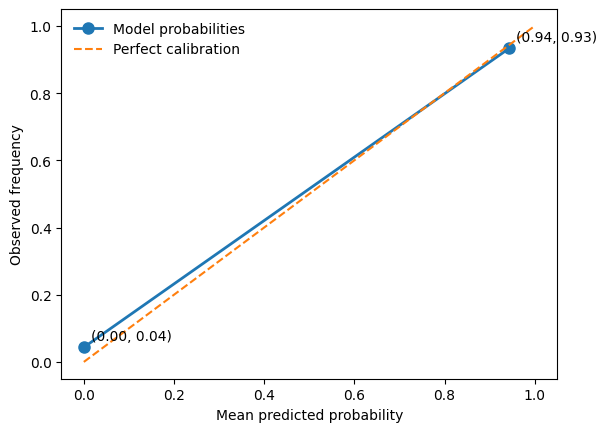

In [65]:
prob_true, prob_pred = calibration_curve(y_val,y_val_prob,n_bins=4,strategy="quantile")
print(pd.DataFrame({"Mean Predicted Probability": prob_pred,"Observed Frequency": prob_true}))

plt.plot(prob_pred,prob_true,marker="o",linewidth=2,markersize=8,label="Model probabilities")
plt.plot([0,1],[0,1],"--",linewidth=1.5,label="Perfect calibration")

for x, y in zip(prob_pred, prob_true):
    plt.annotate(f"({x:.2f}, {y:.2f})",(x, y),textcoords="offset points",xytext=(5,5))

plt.legend(frameon=False)
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.show()

#### Misclassified genomes

In [66]:
results = X_val_inter.copy()

results["True_Label"] = y_val.values
results["Predicted_Label"] = y_val_pred
results["Predicted_Probability"] = y_val_prob

misclassified = results[
    results["True_Label"] != results["Predicted_Label"]
]

print("Misclassified genomes:", len(misclassified))

Misclassified genomes: 4


In [67]:
false_positives = results[
    (results["True_Label"] == 0) &
    (results["Predicted_Label"] == 1)
]

false_negatives = results[
    (results["True_Label"] == 1) &
    (results["Predicted_Label"] == 0)
]

In [68]:
misclassified["Predicted_Probability"].describe()

count    4.00000
mean     0.50250
std      0.51874
min      0.00000
25%      0.08250
50%      0.52500
75%      0.94500
max      0.96000
Name: Predicted_Probability, dtype: float64

In [69]:
misclassified[["True_Label","Predicted_Label","Predicted_Probability"]]

,True_Label,Predicted_Label,Predicted_Probability
Sample_ID,,,
VC_1642,1,0,0.11
VC_1084,0,1,0.96
VC_0031,1,0,0.00
VC_1081,0,1,0.94


In [70]:
X_val_inter.loc[misclassified.index]

,ctxA_3~~~ctxA~~~ctxA_1~~~ctxA_2,ctxB~~~ctxB_2~~~ctxB_1,ftsH_1~~~ftsH_2,gfcB,group_10551,group_10876,group_1116,group_1269,group_13349,group_141,...,group_2332,group_2757,group_3561,group_3598,group_3831,group_4008,group_4377,group_5789,mak,parD1~~~parD1_2~~~parD1_3~~~parD1_1
Sample_ID,,,,,,,,,,,,,,,,,,,,,
VC_1642,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
VC_1084,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,1,0,1,1,0
VC_0031,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
VC_1081,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,1,1,0


In [71]:
X_train_inter.groupby(y_train).mean()

,ctxA_3~~~ctxA~~~ctxA_1~~~ctxA_2,ctxB~~~ctxB_2~~~ctxB_1,ftsH_1~~~ftsH_2,gfcB,group_10551,group_10876,group_1116,group_1269,group_13349,group_141,...,group_2332,group_2757,group_3561,group_3598,group_3831,group_4008,group_4377,group_5789,mak,parD1~~~parD1_2~~~parD1_3~~~parD1_1
serogroup_labels,,,,,,,,,,,,,,,,,,,,,
0,0.126214,0.097087,0.000000,0.592233,0.000000,0.009709,0.058252,0.029126,0.000000,0.019417,...,0.145631,0.174757,0.116505,0.029126,0.106796,0.038835,0.048544,0.864078,0.116505,0.281553
1,0.884444,0.760000,0.004444,0.000000,0.004444,0.000000,0.151111,0.048889,0.004444,0.097778,...,0.262222,0.835556,0.577778,0.048889,0.991111,0.986667,0.048889,0.991111,0.986667,0.128889


#### LOOCV

In [72]:
X_selected = X_labeled[features]

# LOOCV
loo = LeaveOneOut()

# predictions
y_pred = cross_val_predict(final_model,X_selected,y_labeled,cv=loo,n_jobs=-1)

# metrics
print("LOOCV Accuracy:", accuracy_score(y_labeled, y_pred))
print("LOOCV Precision:", precision_score(y_labeled, y_pred, average="macro"))
print("LOOCV Recall:", recall_score(y_labeled, y_pred, average="macro"))
print("LOOCV F1-score:", f1_score(y_labeled, y_pred, average="macro"))

# detailed report
print("\nClassification Report:\n")
print(classification_report(y_labeled, y_pred))

LOOCV Accuracy: 0.975669099756691
LOOCV Precision: 0.9717549068118094
LOOCV Recall: 0.9717549068118094
LOOCV F1-score: 0.9717549068118094

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       129
           1       0.98      0.98      0.98       282

    accuracy                           0.98       411
   macro avg       0.97      0.97      0.97       411
weighted avg       0.98      0.98      0.98       411



### Final predictions

In [73]:
X_unknown = X_unlabeled.loc[:, X_train_inter.columns]

unknown_preds = final_model.predict(X_unknown)
unknown_probs = final_model.predict_proba(X_unknown)[:, 1]

unknown_results = pd.DataFrame({"Predicted_Label": unknown_preds,"Probability_Class1": unknown_probs},index=X_unknown.index)

In [74]:
unknown_results.reset_index(inplace=True)
unknown_results.rename(columns={"index": "Sample_ID"}, inplace=True)
#unknown_results

In [75]:
unknown_results['Predicted_Label'].value_counts()

Predicted_Label
0    777
1    678
Name: count, dtype: int64

>= 0.95: 640
<= 0.05: 683
Between 0.4 and 0.6: 7


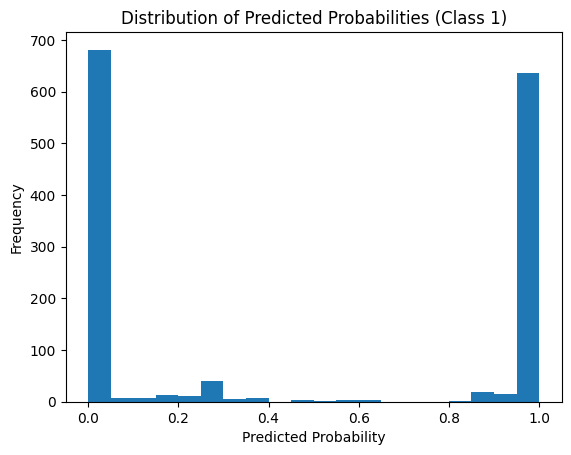

In [76]:
print(">= 0.95:", np.sum(unknown_probs >= 0.95))
print("<= 0.05:", np.sum(unknown_probs <= 0.05))
print("Between 0.4 and 0.6:", np.sum((unknown_probs > 0.4) & (unknown_probs < 0.6)))

plt.figure()
plt.hist(unknown_probs, bins=20)
plt.title("Distribution of Predicted Probabilities (Class 1)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()

### Saving predictions

In [77]:
pred_map = {1: "O1", 0: "non_O1"}
unknown_results["Predicted_serogroup"] = unknown_results["Predicted_Label"].map(pred_map)

unknown_results = unknown_results.rename(columns={"Probability_Class1": "Probability_O1"})
unknown_final = unknown_results[["Sample_ID","Predicted_serogroup","Probability_O1"]].copy()
#unknown_final

In [78]:
label_map = {1: "O1", 0: "non_O1"}
labeled_df = pd.DataFrame({"Sample_ID": X_labeled.index,"Serogroup": y_labeled.map(label_map)})
labeled_df

,Sample_ID,Serogroup
Sample_ID,,
VC_0001,VC_0001,non_O1
VC_0002,VC_0002,non_O1
VC_0003,VC_0003,non_O1
VC_0004,VC_0004,non_O1
VC_0005,VC_0005,non_O1
...,...,...
VC_1861,VC_1861,non_O1
VC_1862,VC_1862,non_O1
VC_1863,VC_1863,non_O1


In [79]:
combined_df = pd.concat([labeled_df, unknown_final],ignore_index=True)

In [80]:
unknown_final.to_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/1_serogroup/2_serogroup_predictions.csv")
combined_df.to_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/1_serogroup/3_serogroup_pred_combined.csv")

## Plots

### ROC AUC

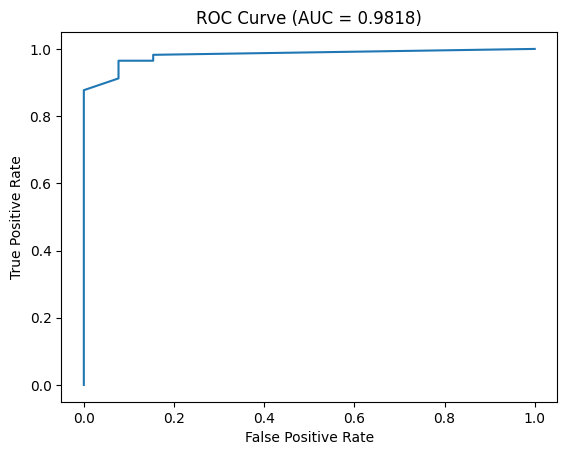

In [81]:
fpr, tpr, _ = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

### Confusion matrix

Text(0.5, 1.0, 'Confusion Matrix')

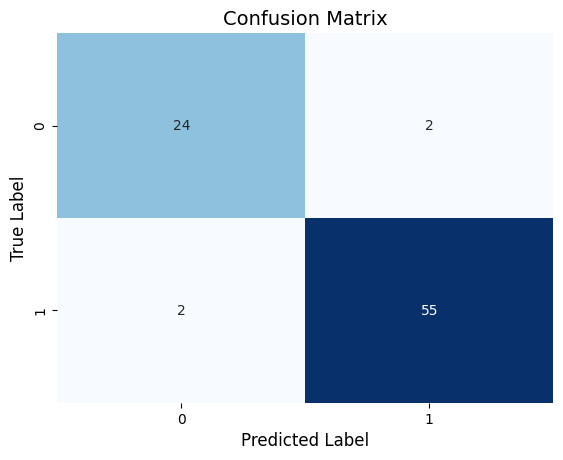

In [82]:
cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)

### Feature importance

In [85]:
label_map = build_label_map(gpa_path)
out_file = "/media/dell/My Passport/vc_files_v_final/3_supervised_learning/1_serogroup/blast_results_hypo_prot.tsv"

Running BLAST for 18 hypothetical genes...
group_4008
  BEFORE: hypothetical protein (group_4008)
  AFTER : Long-chain acyl-protein thioester reductase



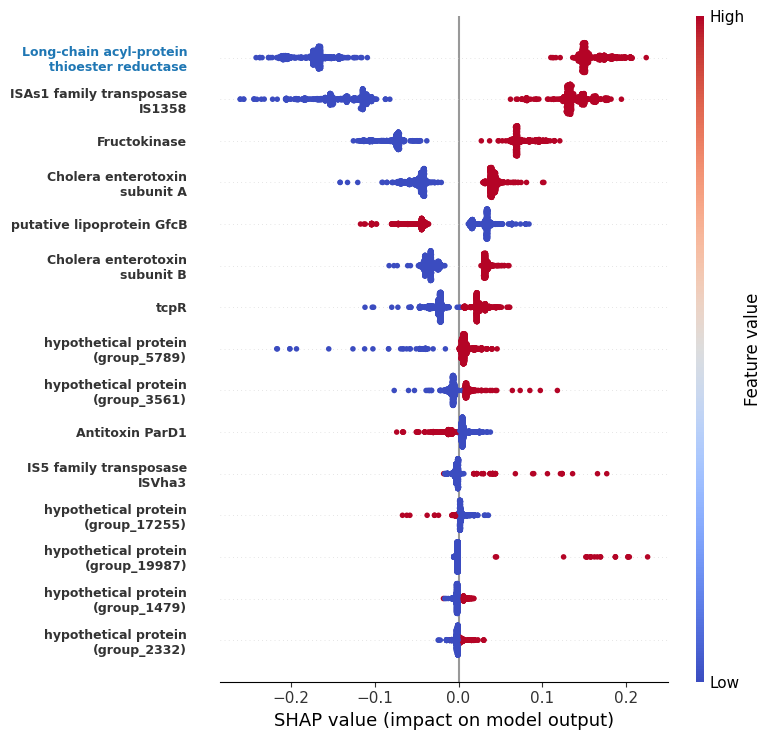

In [86]:
plot_shap_summary(model=final_model,
                  X=X,
                  features=features,
                  label_map=label_map,
                  level="serogroup",
                  fasta_file=fasta_file,
                  blast_db=blast_db,
                  raw_features=oagc_features,
                  max_display=15, 
                  save_path = "/media/dell/My Passport/vc_files_v_final/plots/2_sg_shap.tif")

# Serotype classification

## Dataset preparation

### Labels

In [21]:
clf1_results = pd.read_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/1_serogroup/3_serogroup_pred_combined.csv")
clf1_results = clf1_results.drop(columns=["Unnamed: 0"])
clf1_results["final_serogroup"] = clf1_results["Predicted_serogroup"].fillna(clf1_results["Serogroup"])
#clf1_results
clf1_results['final_serogroup'].value_counts()

final_serogroup
O1        960
non_O1    906
Name: count, dtype: int64

In [22]:
## serotype information
metadata = pd.read_csv("/media/dell/My Passport/vc_files_v_final/1_data_curation/metadata_filtered.csv")
serotype_info = metadata[['Sample_ID','serogroup_serotype']]
#serotype_info
serotype_info = pd.merge(serotype_info, clf1_results, on="Sample_ID")
serotype_info = serotype_info[['Sample_ID','serogroup_serotype','Predicted_serogroup','final_serogroup']]
serotype_info.head()

,Sample_ID,serogroup_serotype,Predicted_serogroup,final_serogroup
0,VC_0001,non_O1,NaN,non_O1
1,VC_0002,non_O1,NaN,non_O1
2,VC_0003,non_O1,NaN,non_O1
3,VC_0004,non_O1,NaN,non_O1
4,VC_0005,non_O1,NaN,non_O1


In [23]:
## droppung non O1 samples
serotype_info = serotype_info[serotype_info['serogroup_serotype'] != 'non_O1']
serotype_info = serotype_info[serotype_info['Predicted_serogroup'] != 'non_O1']
#serotype_info

o1_genomes = serotype_info[['Sample_ID','serogroup_serotype']]
#o1_genomes
o1_genomes['serogroup_serotype'].value_counts()

serogroup_serotype
unkwn           678
O1_Ogawa        106
O1_Inaba         88
O1_unkwn         87
O1_Hikoshima      1
Name: count, dtype: int64

### Feature columns

#### pan data

In [24]:
pan_data = pd.read_csv('/media/dell/My Passport/vc_files_v_final/3_supervised_learning/1_serogroup/gene_presence_absence.Rtab',sep = '\t', index_col=0)
pan_data = pan_data.T
pan_data = pan_data.reset_index()
pan_data = pan_data.rename(columns = {'index':'Sample_ID'})
#pan_data

In [25]:
cols = ["qseqid","sseqid","pident","length","mismatch","gapopen","qstart","qend","sstart","send","evalue","bitscore"]

# oagc blast hit tsv filr
oagc = pd.read_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/oagc/oagc_genes.tsv", sep="\t", names=cols)

oagc_filtered = oagc[(oagc["pident"] >= 80) & (oagc["bitscore"] >= 70)]
# genes showing high sequence similarity (>=80% identity) and strong alignment scores
# (bitscore >=70) were only retained

oagc_filtered = oagc_filtered.drop_duplicates(subset="sseqid")
oagc_filtered.head()

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore
0,NC_002505.1:245143-270435,group_4008,100.000,2478,0,0,12150,14627,1,2478,0.0,4577.0
1,NC_002505.1:245143-270435,ppsB~~~menE_3~~~sauT~~~lcfB,100.000,1416,0,0,9611,11026,1,1416,0.0,2615.0
2,NC_002505.1:245143-270435,group_4824,100.000,1383,0,0,6422,7804,1,1383,0.0,2555.0
3,NC_002505.1:245143-270435,group_2325,97.003,1268,38,0,23977,25244,1,1268,0.0,2132.0
4,NC_002505.1:245143-270435,group_5060,100.000,1125,0,0,11035,12159,1,1125,0.0,2078.0


In [833]:
#oagc.describe()

In [26]:
oagc_filtered.describe()

,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore
count,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,4.700000e+01,47.000000
mean,95.631213,527.829787,19.531915,0.680851,15194.893617,15721.425532,232.574468,638.659574,2.406243e-14,862.334043
std,4.277531,547.119783,33.546108,1.877862,5527.623820,5316.799044,526.658447,635.005282,1.533549e-13,955.894789
min,82.353000,42.000000,0.000000,0.000000,1.000000,945.000000,1.000000,1.000000,0.000000e+00,78.700000
25%,93.333000,87.000000,0.000000,0.000000,14991.500000,15297.500000,1.000000,122.000000,0.000000e+00,134.000000
50%,96.875000,234.000000,5.000000,0.000000,15885.000000,16778.000000,1.000000,522.000000,1.570000e-85,320.000000
75%,100.000000,923.000000,26.000000,0.500000,18316.000000,18405.000000,233.500000,981.500000,2.200000e-29,1402.000000
max,100.000000,2478.000000,149.000000,9.000000,24562.000000,25293.000000,3114.000000,3025.000000,1.050000e-12,4577.000000


In [835]:
# bitscore 56.5–63.9 were removed and the remaining (bitscore ≥78.7) were retained.

In [836]:
#oagc_filtered['sseqid'].value_counts()

In [27]:
oagc_genes = set(oagc_filtered["sseqid"])
len(oagc_genes)

47

In [28]:
matched = []
not_matched = []
for gene in oagc_genes:
    found = any(gene in col for col in pan_data.columns)
    if found:
        matched.append(gene)
    else:
        not_matched.append(gene)

print("Matched genes:", len(matched))
print("Not matched genes:", len(not_matched))

Matched genes: 47
Not matched genes: 0


In [29]:
pan_oagc = pan_data[["Sample_ID"] + matched]  # all the oagc gene_ids match with the presence_absence_data
pan_oagc.head()

Gene,Sample_ID,group_14891,ppsB~~~menE_3~~~sauT~~~lcfB,algC,group_20259,group_13923,tagH~~~btuD_5,group_16562,vioB,group_17450,...,group_1443,rcsC_2,group_16057,group_19096,group_5060,group_2325,group_6158,rfbE_2~~~rfbE,group_14895,group_17072
0,VC_0001,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,VC_0002,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
2,VC_0003,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,VC_0004,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
4,VC_0005,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [30]:
oagc_genes

{'algC',
 'dinB_1~~~dinB~~~dinB_2',
 'group_12926',
 'group_13923',
 'group_1443',
 'group_14629',
 'group_14889',
 'group_14891',
 'group_14895',
 'group_16057',
 'group_16147',
 'group_16562',
 'group_16855',
 'group_17072',
 'group_17450',
 'group_17459',
 'group_17542',
 'group_1820',
 'group_19096',
 'group_19945',
 'group_20259',
 'group_20349',
 'group_20406',
 'group_2054',
 'group_2325',
 'group_2942',
 'group_3291',
 'group_4008',
 'group_4795',
 'group_4824',
 'group_5060',
 'group_5309',
 'group_6158',
 'group_628',
 'group_7888',
 'group_883',
 'group_9961',
 'hldD~~~hldD_1~~~hldD_2',
 'manC1~~~rfbM',
 'mshA_1~~~mshA_3~~~mshA_2',
 'pknD_1~~~pknD_2',
 'ppsB~~~menE_3~~~sauT~~~lcfB',
 'rcsC_2',
 'rfbE_2~~~rfbE',
 'tagH~~~btuD_5',
 'trmR_1',
 'vioB'}

In [840]:
# checked - bitscore threhold added for filtering oagc genes (was missed in the previous analysis) 
# the results were consistent

#### AMR data

In [31]:
path = "/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/4_acc_mge/amr_out"
tsv_files = glob(os.path.join(path, "*.tsv"))

presence_absence = {}
for file in tsv_files:
    base = os.path.basename(file)
    sample_id = base.replace(".tsv", "")
    df = pd.read_csv(file, sep="\t")
    genes = df["Element symbol"].dropna().unique()
    presence_absence[sample_id] = {gene: 1 for gene in genes}

presence_df = pd.DataFrame.from_dict(presence_absence, orient='index')
presence_df = presence_df.fillna(0).astype(int)

presence_df = presence_df.reset_index().rename(columns={"index": "Sample_ID"})
#presence_df
#presence_df.to_csv('/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/3_supervised_ml/2_serotype_files/amr_presence.csv')

In [32]:
amr_data = pd.read_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/amr_presence.csv")
amr_data = amr_data.drop('Unnamed: 0',axis=1)
dataset = pd.merge(amr_data, pan_oagc, on='Sample_ID')

In [33]:
len(amr_data.columns)

121

In [34]:
dataset.shape

(1866, 168)

#### Virulence data

In [35]:
path = "/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/4_acc_mge/vir_out"
tsv_files = glob(os.path.join(path, "*.tsv"))

presence_absence = {}
for file in tsv_files:
    base = os.path.basename(file)
    sample_id = base.replace(".tsv", "")
    df = pd.read_csv(file, sep="\t")
    genes = df["GENE"].dropna().unique()
    presence_absence[sample_id] = {gene: 1 for gene in genes}

vir_df = pd.DataFrame.from_dict(presence_absence, orient='index')
vir_df = vir_df.fillna(0).astype(int)

vir_df = vir_df.reset_index().rename(columns={"index": "Sample_ID"})
#vir_df
#vir_df.to_csv('/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/3_supervised_ml/2_serotype_files/vir_presence.csv')

In [36]:
vir_data = pd.read_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/vir_presence.csv")
vir_data = vir_data.drop('Unnamed: 0',axis=1)
dataset = pd.merge(dataset, vir_data, on='Sample_ID')

In [37]:
len(vir_data.columns)

51

In [38]:
dataset.shape

(1866, 218)

#### Integron data

In [39]:
base_dir = "/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/4_acc_mge/bacant_out"
presence = {}

for genome in os.listdir(base_dir):
    folder = os.path.join(base_dir, genome)
    if not os.path.isdir(folder):
        continue

    presence[genome] = {}

    file_path = os.path.join(folder, "integron.filter.tsv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t")
        if "INTEGRON TYPE|ACCESSION" in df.columns:
            elements = df["INTEGRON TYPE|ACCESSION"].dropna().unique()
            presence[genome] = {e: 1 for e in elements}

all_elements = sorted({e for d in presence.values() for e in d})

matrix = pd.DataFrame(0, index=sorted(presence.keys()), columns=all_elements)

for genome, elements in presence.items():
    for e in elements:
        matrix.loc[genome, e] = 1

matrix = matrix.reset_index()
#matrix.to_csv('/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/3_supervised_ml/2_serotype_files/int_presence.csv')

In [40]:
integron_data = pd.read_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/int_presence.csv")
integron_data = integron_data.rename(columns={'index': 'Sample_ID'})
integron_data = integron_data.drop("Unnamed: 0", axis=1)
dataset = pd.merge(dataset, integron_data, on='Sample_ID')

In [41]:
len(integron_data.columns)

45

In [42]:
dataset.shape

(1866, 262)

#### Transposon data

In [43]:
base_dir = "/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/4_acc_mge/bacant_out"
presence = {}

for genome in os.listdir(base_dir):
    folder = os.path.join(base_dir, genome)

    if not os.path.isdir(folder):
        continue

    presence[genome] = {}

    tsv_path = os.path.join(folder, "transposon.filter.tsv")
    xls_path = os.path.join(folder, "transposon.filter.xls")

    if os.path.exists(tsv_path):
        df = pd.read_csv(tsv_path, sep="\t")
    elif os.path.exists(xls_path):
        df = pd.read_csv(xls_path, sep="\t")
    else:
        continue

    if "TRANSPOSON TYPE|ACCESSION" not in df.columns:
        continue

    elements = df["TRANSPOSON TYPE|ACCESSION"].dropna().unique()
    presence[genome] = {e: 1 for e in elements}

all_elements = sorted({e for d in presence.values() for e in d})

matrix = pd.DataFrame(0, index=sorted(presence.keys()), columns=all_elements)

for genome, elements in presence.items():
    for e in elements:
        matrix.loc[genome, e] = 1

matrix = matrix.reset_index()
#matrix.to_csv('/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/3_supervised_ml/2_serotype_files/transposon_presence.csv')

In [44]:
transposon_data = pd.read_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/transposon_presence.csv")
transposon_data = transposon_data.rename(columns={'index': 'Sample_ID'})
transposon_data = transposon_data.drop("Unnamed: 0", axis=1)
dataset = pd.merge(dataset, transposon_data, on='Sample_ID')

In [45]:
len(transposon_data.columns)

24

In [46]:
dataset.shape

(1866, 285)

#### wbet info

In [47]:
pa = pd.read_csv("/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/1_pan_data/panaroo_out/gene_presence_absence.csv",low_memory=False)

group_4795= pa[pa["Gene"] == "group_4795"]  # wbeT gene aligned with group_4795 seq from pan_reference.fa
group_4795

,Gene,Non-unique Gene name,Annotation,VC_0001,VC_0002,VC_0003,VC_0004,VC_0005,VC_0006,VC_0007,...,VC_1857,VC_1858,VC_1859,VC_1860,VC_1861,VC_1862,VC_1863,VC_1864,VC_1865,VC_1866
3267,group_4795,NaN,hypothetical protein,NaN,NaN,NaN,NaN,NaN,NaN,6_refound_169_pseudo,...,OPMNOHKO_01784,KLNPOCKA_01634,NaN,NaN,NaN,NaN,LEIMCIMF_01274,PMKHFBGH_02877,NaN,NaN


In [48]:
meta_cols = ["Gene", "Non-unique Gene name", "Annotation"]     # required columns from gene presence_absence.csv
genome_cols = [col for col in group_4795.columns if col not in meta_cols]
# each row = one gene present in the particular genome
annotation_df = group_4795.melt(id_vars=["Gene"],value_vars=genome_cols,var_name="gff_file",value_name="annotation_id")

annotation_df = annotation_df.dropna()
annotation_df.head()    # only for wbeT gene, more columns are added in the next cell

,Gene,gff_file,annotation_id
6,group_4795,VC_0007,6_refound_169_pseudo
13,group_4795,VC_0014,FLJNCJKA_02417
14,group_4795,VC_0015,KNKEGLGM_00657
15,group_4795,VC_0016,JBOEBDMD_00371
16,group_4795,VC_0017,KGPHHLDO_03553


In [49]:
file_path = "/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/1_pan_data/panaroo_out/gene_data.csv"
# The file was too large to load with read_csv
results = []

for chunk in pd.read_csv(file_path, chunksize=100000):   # loading 1 lakh rows at a time
    merged = chunk.merge(annotation_df,on=["gff_file", "annotation_id"],how="inner") # merge based on genome id and gene id
    if not merged.empty:
        results.append(merged)  # appending the matches to merged

group4795_sequences = pd.concat(results)

group4795_sequences = group4795_sequences[["gff_file", "scaffold_name", "annotation_id","dna_sequence", "prot_sequence"]]

group4795_sequences.head()
group4795_sequences = group4795_sequences.rename(columns={'gff_file':'Sample_ID'})

/tmp/ipykernel_4537/1228780971.py:5: DtypeWarning: Columns (0: gene_name) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=100000):   # loading 1 lakh rows at a time


In [50]:
# group_4755_sequences df contains the dna and the protein sequences of wbet gene for each genome
#print(group4795_sequences["dna_sequence"].str.len().describe())

In [51]:
#print(group4795_sequences["prot_sequence"].str.len().describe())

In [52]:
df = group4795_sequences[['Sample_ID', 'dna_sequence', 'prot_sequence']].copy()

# for cases where wbet hits were not found tehy were filled with '-1'
df['has_hit'] = df['dna_sequence'].notna().astype(int)
df['frag_len'] = df['dna_sequence'].apply(lambda x: len(x) if pd.notna(x) else -1)
df['aa_length'] = df['prot_sequence'].apply(lambda x: len(x) if pd.notna(x) else -1)
df['internal_stop_codons'] = df['prot_sequence'].apply(lambda x: x[:-1].count('*') if pd.notna(x) else -1)  
# Count the number of * inside the protein sequence (final expected stop codon is excluded

summary_table = df[['Sample_ID','has_hit','aa_length','internal_stop_codons','frag_len']]
summary_table.to_csv('/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/wbeT_info_panaroo.csv')

In [53]:
seq_hit_data = pd.read_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/wbeT_info_panaroo.csv")
seq_hit_data = seq_hit_data.drop("Unnamed: 0", axis=1)
dataset = pd.merge(dataset,seq_hit_data,on='Sample_ID',how='left').fillna('-1')

In [54]:
wbet_cols = ['has_hit', 'aa_length','internal_stop_codons', 'frag_len']
dataset[wbet_cols].describe()

,has_hit,aa_length,internal_stop_codons,frag_len
count,1866,1866,1866,1866
unique,2,32,2,33
top,-1,-1,-1,-1
freq,942,942,942,942


In [55]:
len(seq_hit_data.columns)

5

In [56]:
dataset.shape

(1866, 289)

#### Phage data

In [57]:
## virsorter output
base_dir = "/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/server_files/napbl_server_files/virsorter2_out"
results = []

for genome in sorted(os.listdir(base_dir)):
    g_path = os.path.join(base_dir, genome)
    if not os.path.isdir(g_path):
        continue
    
    score_file = os.path.join(g_path, "final-viral-score.tsv")
    dsdna = 0
    ssdna = 0
    
    if os.path.exists(score_file):
        df = pd.read_csv(score_file, sep="\t")
        df = df[df["max_score"] >= 0.5]   
        df["max_score_group"] = df["max_score_group"].str.lower()
        if any(df["max_score_group"] == "dsdnaphage"):
            dsdna = 1
        
        if any(df["max_score_group"] == "ssdna"):
            ssdna = 1
    
    results.append({"Sample_ID": genome,"dsDNA": dsdna,"ssDNA": ssdna})
    
phage_df = pd.DataFrame(results)
#phage_df.to_csv('/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/3_supervised_ml/2_serotype_files/phage_virsorter_presence.csv')
phage_df

,Sample_ID,dsDNA,ssDNA
0,VC_0001,1,0
1,VC_0002,0,1
2,VC_0003,1,1
3,VC_0004,0,1
4,VC_0005,1,1
...,...,...,...
1861,VC_1862,1,1
1862,VC_1863,1,1
1863,VC_1864,1,1
1864,VC_1865,1,0


In [58]:
dataset = pd.merge(dataset,phage_df,on='Sample_ID',how='left').fillna('-1')

In [59]:
len(phage_df.columns)

3

In [60]:
dataset.shape

(1866, 291)

In [61]:
## prophage - phispy
base_dir = "/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/server_files/napbl_server_files/phispy_out"
results = []

for genome in sorted(os.listdir(base_dir)):
    g_path = os.path.join(base_dir, genome)
    if not os.path.isdir(g_path):
        continue
    
    prophage_file = os.path.join(g_path, "prophage_coordinates.tsv")
    presence = 0
    
    if os.path.isfile(prophage_file):
        try:
            df = pd.read_csv(prophage_file, sep="\t")
            if not df.empty:
                presence = 1
        
        except pd.errors.EmptyDataError:
            presence = 0
    
    results.append({"Sample_ID": genome,"Prophage_present": presence})

prophage_df = pd.DataFrame(results)
#prophage_df.to_csv('/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/3_supervised_ml/2_serotype_files/phage_phispy_presence.csv')
prophage_df

,Sample_ID,Prophage_present
0,VC_0001,0
1,VC_0002,0
2,VC_0003,0
3,VC_0004,0
4,VC_0005,0
...,...,...
1861,VC_1862,0
1862,VC_1863,0
1863,VC_1864,0
1864,VC_1865,0


In [62]:
dataset = pd.merge(dataset,prophage_df,on='Sample_ID',how='left').fillna('-1')

In [63]:
dataset.shape

(1866, 292)

#### Plasmid data

In [64]:
base_dir = "/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/server_files/pbl_lab_server_files/plasmid_out"
results = []

for file in sorted(os.listdir(base_dir)):
    
    if not file.endswith(".tsv"):
        continue
    
    genome = file.replace(".tsv", "")
    fpath = os.path.join(base_dir, file)
    df = pd.read_csv(fpath, sep="\t")
    df = df[(df["%IDENTITY"] >= 90) & (df["%COVERAGE"] >= 60)]
    presence = 1 if len(df) > 0 else 0
    results.append({"Sample_ID": genome,"Plasmid_present": presence})

plasmid_df = pd.DataFrame(results)
#plasmid_df.to_csv('/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/3_supervised_ml/2_serotype_files/plasmid_presence.csv')
plasmid_df

,Sample_ID,Plasmid_present
0,VC_0001,0
1,VC_0002,0
2,VC_0003,0
3,VC_0004,0
4,VC_0005,0
...,...,...
1861,VC_1862,0
1862,VC_1863,0
1863,VC_1864,0
1864,VC_1865,0


In [65]:
dataset = pd.merge(dataset,plasmid_df,on='Sample_ID',how='left').fillna('-1')

In [66]:
dataset.shape

(1866, 293)

#### Serotype info

In [67]:
dataset = pd.merge(dataset, serotype_info, on = 'Sample_ID')

In [68]:
dataset['serogroup_serotype'] = dataset['serogroup_serotype'].replace({'O1_unkwn': 'unkwn'}) 
# O1_unkwn is not considered for training and evaluation
dataset['serogroup_serotype'].value_counts()

serogroup_serotype
unkwn           765
O1_Ogawa        106
O1_Inaba         88
O1_Hikoshima      1
Name: count, dtype: int64

In [69]:
dataset.shape

(960, 296)

#### Label encoding

In [70]:
dataset = dataset[dataset['serogroup_serotype'] != 'O1_Hikoshima']   # Hikoshima was not included for training, evaluation and prediction
clf2_dataset = dataset.copy()
clf2_labels = {'O1_Ogawa':1,'O1_Inaba':0,'unkwn':-1}
clf2_dataset["serotype_labels"] = (clf2_dataset["serogroup_serotype"].str.strip().map(clf2_labels))
clf2_dataset['serotype_labels'].value_counts()

serotype_labels
-1    765
 1    106
 0     88
Name: count, dtype: int64

In [81]:
clf2_dataset.to_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/1_clf2_dataset.csv")

In [72]:
#print(clf2_dataset.columns.tolist())

In [80]:
clf2_dataset.shape

(959, 297)

## Supervised ML serotype classification

### Loading dataset

In [82]:
dataset = pd.read_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/1_clf2_dataset.csv")
dataset = dataset.set_index('Sample_ID')
dataset = dataset.drop(columns =['Unnamed: 0'])
dataset['serotype_labels'].value_counts()

serotype_labels
-1    765
 1    106
 0     88
Name: count, dtype: int64

In [83]:
dataset.shape

(959, 296)

### Feature label split

In [84]:
X = dataset.drop(['serogroup_serotype','final_serogroup','serotype_labels','Predicted_serogroup'], axis=1)
y = dataset['serotype_labels']

In [85]:
X_unlabeled = X[y == -1]
X_labeled = X[y != -1]
y_labeled = y[y!= -1]

### Train validation split

In [86]:
X_train, X_val, y_train, y_val = train_test_split(X_labeled,y_labeled,test_size = 0.2, stratify = y_labeled, random_state = 42)

In [87]:
print(X_train.shape)
print(X_val.shape)

print(set(X_train.columns) == set(X_val.columns))
print(len(set(X_train.index) & set(X_val.index)))

(155, 292)
(39, 292)
True
0


### Feature selection

In [172]:
results = combined_feature_selection(X_train, y_train, X_val,lasso_params={},boruta_params={})
X_train_lasso, X_val_lasso, lasso_features, lasso_freq = results["lasso"]
X_train_boruta, X_val_boruta, boruta_features, boruta_freq = results["boruta"]
X_train_intersection, X_val_intersection, common_features = results["intersection"]

Stable LASSO features: 36
Selected Boruta features: 26
LASSO features: 36
Boruta features: 26
Intersection: 18


In [173]:
#results = combined_feature_selection(X_train, y_train, X_val,
                                     #lasso_params={"cv": StratifiedKFold(n_splits=10,shuffle=True,random_state=42)},
                                     #boruta_params={})
#X_train_lasso, X_val_lasso, lasso_features, lasso_freq = results["lasso"]
#X_train_boruta, X_val_boruta, boruta_features, boruta_freq = results["boruta"]
#X_train_intersection, X_val_intersection, common_features = results["intersection"]

In [176]:
boruta_features

Index(['floR', 'aph(6)-Id', 'aph(3'')-Ib', 'sul2', 'dfrA1', 'gyrA_S83I',
       'parC_S85L', 'qnrD1', 'tet(59)', 'dfrA31', 'qnrVC1', 'group_3291',
       'vgrG-2', 'tcpN/toxT', 'tcpR', 'In1326|CP016446', 'In1291|KU145265',
       'In363|DQ402098', 'In251|HQ386834', 'frag_len', 'ssDNA',
       'In444|GQ891757', 'aa_length', 'Plasmid_present', 'hcp-2', 'tcpS'],
      dtype='str')

In [166]:
df_scores, summary_stats,train_metrics_df = compute_cv_scores(X_train_lasso,X_train_boruta,X_train_intersection,y_train)
summary_stats

,Model,mean_ROC_AUC,sd_ROC_AUC
0,Logistic + LASSO,0.945933,0.073080
1,Logistic + intersection,0.905258,0.076613
2,RF + Boruta,0.939187,0.051587
3,RF + LASSO,0.946726,0.049740
4,RF + intersection,0.941567,0.051180


In [167]:
train_metrics_df

,Model,Train Accuracy,Train F1
0,RF + LASSO,0.980645,0.982249
1,RF + Boruta,0.980645,0.982249
2,Logistic + LASSO,0.954839,0.958084
3,Logistic + intersection,0.870968,0.880952
4,RF + intersection,0.980645,0.982249


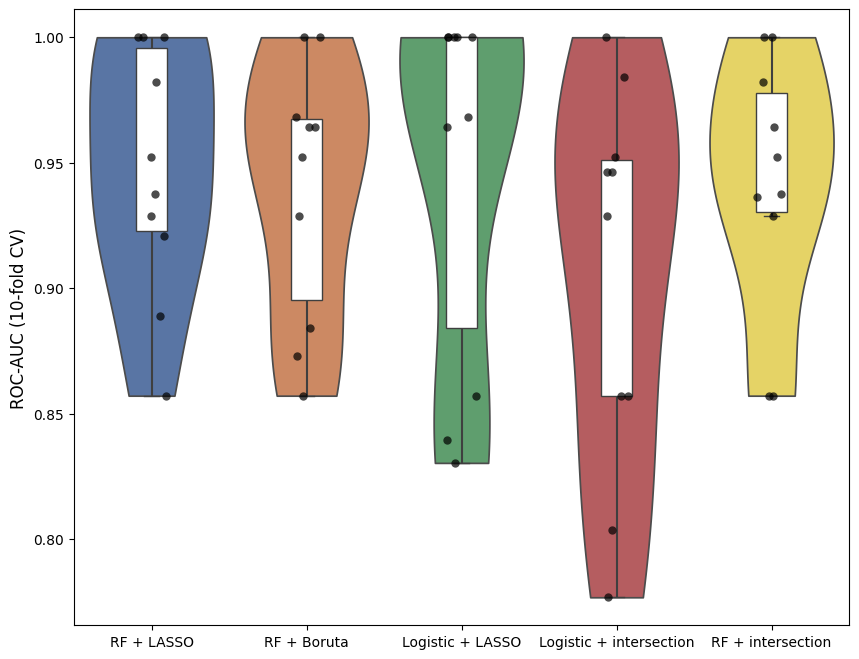

In [93]:
plot_cv_results(df_scores, save_path='/media/dell/My Passport/vc_files_v_final/plots/1_st_class_ml.tif')

In [94]:
# LASSO set was chosen for further training
# RF -> best with LASSO set (higher ROC AUC and lower standard deviation) 
# Log_reg -> best with LASSO set (higher ROC AUC and lower standard deviation)

### Multicollinearity

In [95]:
## only binary features were considered
wbet_cols = ['has_hit', 'aa_length','internal_stop_codons', 'frag_len']

X_train_lasso = pd.DataFrame(X_train_lasso, columns=lasso_features)  # convert to dataframe (since LASSO output was numpy)
X_val_lasso   = pd.DataFrame(X_val_lasso, columns=lasso_features)

X_train_lasso = X_train_lasso.reindex(sorted(X_train_lasso.columns), axis=1)   # alphabetical sortimg is done
X_val_lasso   = X_val_lasso.reindex(sorted(X_val_lasso.columns), axis=1)   # same features are retained for every run

cols_for_corr = [c for c in X_train_lasso.columns if c not in wbet_cols]  # wbet features were not considered

corr_matrix = X_train_lasso[cols_for_corr].corr(method="spearman").abs()
#corr_matrix

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  #  only upper triangle to avoid duplicate correlation

to_drop = []
for col in upper.columns:
    if any(upper[col] > 0.97):
        to_drop.append(col)    # highly correlated features (> 0.97)

print("Number of correlated features:", len(to_drop))  # total features that are to be dropped

X_train_lasso = X_train_lasso.drop(columns=to_drop)   # filtering in train set (wbet_cols are automatically retained)
X_val_lasso   = X_val_lasso.drop(columns=[c for c in to_drop if c in X_val_lasso.columns])   # filtering for validation set

print("Final feature count:", X_train_lasso.shape[1])  # final feature count

Number of correlated features: 1
Final feature count: 35


In [96]:
pairs_df = (upper.stack().reset_index())
pairs_df.columns = ["Feature1", "Feature2", "Correlation"]

pairs_df = pairs_df[pairs_df["Correlation"] > 0.97]
pairs_df

,Feature1,Feature2,Correlation
467,group_6158,manC1~~~rfbM,1.0


In [97]:
results = []

for name, model in models_bcv:
    res = train_and_evaluate_basic(name, model,X_train_lasso, y_train,X_val_lasso, y_val)
    results.append(res)

In [98]:
df_bcv = pd.DataFrame(results)
df_bcv = df_bcv.round(3)
df_bcv = df_bcv.sort_values(by=["F1-score (macro)", "ROC AUC"], ascending=False)
df_bcv.to_csv('/media/dell/My Passport/vc_files_v_final/tables/1_st_class_metrics_beforecv.csv')
df_bcv

,Model,Train Accuracy,Test Accuracy,Precision (macro),Recall (macro),F1-score (macro),ROC AUC
3,KNN,0.890,0.769,0.774,0.774,0.769,0.828
2,SVC,0.955,0.769,0.774,0.774,0.769,0.788
0,Logistic Regression,0.955,0.769,0.785,0.778,0.769,0.746
5,Random Forest,0.981,0.744,0.745,0.746,0.743,0.836
7,XGBoost,0.974,0.718,0.722,0.722,0.718,0.772
6,Extra Trees,0.981,0.692,0.693,0.694,0.692,0.811
1,Decision Tree,0.981,0.667,0.679,0.675,0.666,0.688
4,Naive Bayes,0.574,0.564,0.633,0.587,0.533,0.714


In [99]:
# consistent with the previous results

### Model training after CV and tuning

In [100]:
results_cv = []

for name, model, params in models_cv:
    res_cv = train_and_evaluate_cv(name, model, params,X_train_lasso, y_train,X_val_lasso, y_val,cv=cv)
    results_cv.append(res_cv)

In [101]:
df_cv = pd.DataFrame(results_cv)
df_cv = df_cv.round(3)
df_cv = df_cv.sort_values(by=["F1-score (macro)", "ROC AUC"],ascending=False)
df_cv.to_csv('/media/dell/My Passport/vc_files_v_final/tables/1_st_class_metrics_aftercv.csv')
df_cv

,Model,Best Params,CV Score,Train Accuracy,Test Accuracy,Precision (macro),Recall (macro),F1-score (macro),ROC AUC,Best Estimator
7,XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.855,0.910,0.821,0.825,0.825,0.821,0.810,"XGBClassifier(base_score=None, booster=None, c..."
6,Extra Trees,"{'max_depth': 5, 'max_features': 'sqrt', 'min_...",0.875,0.961,0.795,0.796,0.798,0.795,0.823,"(ExtraTreeClassifier(max_depth=5, min_samples_..."
2,SVC,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.888,0.955,0.769,0.774,0.774,0.769,0.788,"SVC(C=1, class_weight='balanced', probability=..."
0,Logistic Regression,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.894,0.955,0.769,0.785,0.778,0.769,0.746,"LogisticRegression(C=1, class_weight='balanced..."
3,KNN,"{'n_neighbors': 5, 'weights': 'distance'}",0.875,0.981,0.744,0.745,0.746,0.743,0.819,KNeighborsClassifier(weights='distance')
5,Random Forest,"{'max_depth': 5, 'max_features': 'sqrt', 'min_...",0.894,0.948,0.744,0.742,0.742,0.742,0.807,"(DecisionTreeClassifier(max_depth=5, max_featu..."
1,Decision Tree,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.849,0.955,0.667,0.671,0.671,0.667,0.688,DecisionTreeClassifier(class_weight='balanced'...
4,Naive Bayes,{},0.520,0.574,0.564,0.633,0.587,0.533,0.714,GaussianNB()


In [102]:
# consistent with the previous results

### data leakage

In [103]:
# data leakage check with logistic regression on the complete dataset 
# reason: it is a simple model,if data is random it will not perform well
y_train_shuffled = shuffle(y_train, random_state=42)

model_dl_check = LogisticRegression(max_iter=3000)
model_dl_check.fit(X_train, y_train_shuffled)

y_pred_df_check = model_dl_check.predict(X_val)
y_prob_dl_check = model_dl_check.predict_proba(X_val)[:, 1]

print("ROC AUC:", roc_auc_score(y_val, y_prob_dl_check))

ROC AUC: 0.42857142857142855


In [104]:
xgb_dl_check = xgb.XGBClassifier(eval_metric="logloss", random_state=42,n_jobs=1)
xgb_dl_check.fit(X_train_lasso, y_train_shuffled)

y_prob_dl_check = xgb_dl_check.predict_proba(X_val_lasso)[:, 1]

print("ROC AUC:", roc_auc_score(y_val, y_prob_dl_check))

ROC AUC: 0.5370370370370371


### Training of best model with all features for comparison

In [105]:
xgb_model_all_feat = xgb.XGBClassifier(eval_metric="logloss",random_state=42,n_jobs=1)
xgb_params_all_feat = {"n_estimators": [100],"max_depth": [3, 5],"learning_rate": [0.1]}

# model training
models_all_feat = [("XGBoost", xgb_model_all_feat, xgb_params_all_feat)]

In [106]:
results_cv_all_feat = []

for name, model, params in models_all_feat:
    res_cv_all_feat = train_and_evaluate_cv(name, model, params,X_train, y_train,X_val, y_val,cv=5)
    results_cv_all_feat.append(res_cv_all_feat)

In [107]:
df_cv_all_feat = pd.DataFrame(results_cv_all_feat)
df_cv_all_feat = df_cv_all_feat.round(3)
df_cv_all_feat

,Model,Best Params,CV Score,Train Accuracy,Test Accuracy,Precision (macro),Recall (macro),F1-score (macro),ROC AUC,Best Estimator
0,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.85,0.955,0.718,0.722,0.722,0.718,0.804,"XGBClassifier(base_score=None, booster=None, c..."


### Saving the best model

In [108]:
best_model = df_cv.iloc[0]["Best Estimator"]
best_model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [109]:
joblib.dump(best_model, "/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/best_serotype_model.pkl")
joblib.dump(X_train_lasso.columns.tolist(), "/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/model_features.pkl")

['/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/model_features.pkl']

### Model evaluation

In [110]:
final_model = joblib.load("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/best_serotype_model.pkl")
features = joblib.load("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/model_features.pkl")

In [111]:
y_val_pred = final_model.predict(X_val_lasso)
y_val_prob = final_model.predict_proba(X_val_lasso)[:, 1]

val_metrics = {
    "Accuracy": accuracy_score(y_val, y_val_pred),
    "Precision (Macro)": precision_score(y_val, y_val_pred, average="macro"),
    "Recall (Macro)": recall_score(y_val, y_val_pred, average="macro"),
    "F1 (Macro)": f1_score(y_val, y_val_pred, average="macro"),
    "ROC_AUC": roc_auc_score(y_val, y_val_prob),
    'Brier Score': brier_score_loss(y_val, y_val_prob)
}

val_metrics

{'Accuracy': 0.8205128205128205,
 'Precision (Macro)': 0.8253968253968254,
 'Recall (Macro)': 0.8253968253968254,
 'F1 (Macro)': 0.8205128205128205,
 'ROC_AUC': 0.8095238095238095,
 'Brier Score': 0.1717840116614247}

In [112]:
bins = pd.cut(y_val_prob, bins=5)
pd.DataFrame({"prob": y_val_prob,"true": y_val}).groupby(bins).size()

(0.113, 0.275]     8
(0.275, 0.436]    11
(0.436, 0.597]     2
(0.597, 0.759]     8
(0.759, 0.92]     10
dtype: int64

#### Confusion matrix and classification report

In [113]:
cm = confusion_matrix(y_val, y_val_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[16  2]
 [ 5 16]]


In [114]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.76      0.89      0.82        18
           1       0.89      0.76      0.82        21

    accuracy                           0.82        39
   macro avg       0.83      0.83      0.82        39
weighted avg       0.83      0.82      0.82        39



#### Calibration

   Mean Predicted Probability  Observed Frequency
0                    0.212000            0.300000
1                    0.370646            0.200000
2                    0.637727            0.777778
3                    0.854577            0.900000


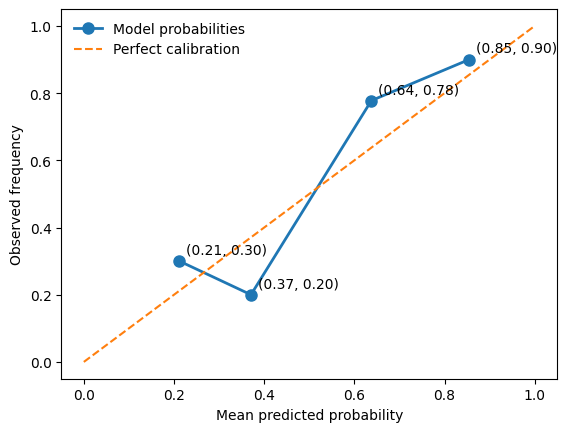

In [115]:
prob_true, prob_pred = calibration_curve(y_val,y_val_prob,n_bins=4,strategy="quantile")
print(pd.DataFrame({"Mean Predicted Probability": prob_pred,"Observed Frequency": prob_true}))

plt.plot(prob_pred,prob_true,marker="o",linewidth=2,markersize=8,label="Model probabilities")
plt.plot([0,1],[0,1],"--",linewidth=1.5,label="Perfect calibration")

for x, y in zip(prob_pred, prob_true):
    plt.annotate(f"({x:.2f}, {y:.2f})",(x, y),textcoords="offset points",xytext=(5,5))

plt.legend(frameon=False)
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.show()

### Misclassified genomes

In [116]:
results = X_val_lasso.copy()

results["True_Label"] = y_val.values
results["Predicted_Label"] = y_val_pred
results["Predicted_Probability"] = y_val_prob

misclassified = results[
    results["True_Label"] != results["Predicted_Label"]
]

print("Misclassified genomes:", len(misclassified))

Misclassified genomes: 7


In [117]:
false_positives = results[
    (results["True_Label"] == 0) &
    (results["Predicted_Label"] == 1)
]

false_negatives = results[
    (results["True_Label"] == 1) &
    (results["Predicted_Label"] == 0)
]

In [118]:
misclassified["Predicted_Probability"].describe()

count    7.000000
mean     0.390127
std      0.252064
min      0.129924
25%      0.204510
50%      0.347503
75%      0.523443
max      0.797556
Name: Predicted_Probability, dtype: float64

In [119]:
misclassified[["True_Label","Predicted_Label","Predicted_Probability"]]

,True_Label,Predicted_Label,Predicted_Probability
1,0,1,0.665888
2,1,0,0.222689
8,1,0,0.129924
9,1,0,0.347503
11,1,0,0.380999
27,0,1,0.797556
35,1,0,0.186331


In [120]:
X_val_lasso.loc[misclassified.index]

,In1291|KU145265,In1368|KY047413,In251|HQ386834,In444|GQ891757,In805|KU886277,Plasmid_present,Prophage_present,aa_length,acfD,catB9,...,qnrD,qnrD1,rtxA,ssDNA,tcpN/toxT,tcpR,tcpS,tet(59),tet(A),vgrG-2
1,-0.569900,-0.114332,-0.827516,0.838628,0.080582,-0.315104,-0.200670,0.742526,0.302571,0.200670,...,-0.114332,-0.248282,0.182574,-2.041241,0.559964,0.469545,0.406711,-0.599708,-0.182574,0.417424
2,-0.569900,-0.114332,-0.827516,0.838628,0.080582,-0.315104,4.983305,-2.313180,-3.305008,-4.983305,...,-0.114332,-0.248282,0.182574,0.489898,-1.785830,-2.129722,-2.458751,-0.599708,-0.182574,-2.395648
8,1.754693,-0.114332,-0.827516,-1.192424,0.080582,-0.315104,-0.200670,-2.313180,0.302571,0.200670,...,-0.114332,-0.248282,0.182574,0.489898,0.559964,0.469545,0.406711,-0.599708,-0.182574,0.417424
9,-0.569900,-0.114332,-0.827516,-1.192424,0.080582,-0.315104,4.983305,0.600400,0.302571,0.200670,...,-0.114332,-0.248282,0.182574,-2.041241,-1.785830,0.469545,0.406711,-0.599708,-0.182574,0.417424
11,-0.569900,-0.114332,-0.827516,-1.192424,0.080582,-0.315104,-0.200670,0.600400,0.302571,0.200670,...,-0.114332,-0.248282,0.182574,0.489898,0.559964,0.469545,0.406711,-0.599708,-0.182574,0.417424
27,1.754693,-0.114332,-0.827516,0.838628,0.080582,-0.315104,-0.200670,0.600400,0.302571,0.200670,...,-0.114332,-0.248282,0.182574,0.489898,0.559964,0.469545,0.406711,-0.599708,-0.182574,-2.395648
35,-0.569900,-0.114332,-0.827516,0.838628,0.080582,-0.315104,-0.200670,-0.607670,0.302571,-4.983305,...,-0.114332,-0.248282,-5.477226,0.489898,0.559964,0.469545,0.406711,-0.599708,-0.182574,0.417424


In [121]:
X_train_lasso.groupby(y_train).mean()

,In1291|KU145265,In1368|KY047413,In251|HQ386834,In444|GQ891757,In805|KU886277,Plasmid_present,Prophage_present,aa_length,acfD,catB9,...,qnrD,qnrD1,rtxA,ssDNA,tcpN/toxT,tcpR,tcpS,tet(59),tet(A),vgrG-2
serotype_labels,,,,,,,,,,,,,,,,,,,,,


#### Extra

In [911]:
y_val_probs = final_model.predict_proba(X_val_lasso)
print("Predicted probabilities:\n", y_val_prob)

Predicted probabilities:
 [0.29006168 0.6658876  0.22268878 0.88052857 0.37452456 0.6892461
 0.16143513 0.81175923 0.12992442 0.3475034  0.8560735  0.38099876
 0.2753706  0.6336809  0.26494113 0.8522016  0.919859   0.34140658
 0.11364871 0.9161084  0.6909246  0.37452456 0.49020308 0.9087963
 0.37452456 0.37452456 0.48209065 0.79755646 0.26854083 0.79112774
 0.6890697  0.36629793 0.6043333  0.2753706  0.6025909  0.18633124
 0.81175923 0.6736095  0.22175194]


In [912]:
y_val_probs_pos = y_val_probs[:, 1]
print("Positive class probabilities:\n", y_val_probs_pos)

Positive class probabilities:
 [0.29006168 0.6658876  0.22268878 0.88052857 0.37452456 0.6892461
 0.16143513 0.81175923 0.12992442 0.3475034  0.8560735  0.38099876
 0.2753706  0.6336809  0.26494113 0.8522016  0.919859   0.34140658
 0.11364871 0.9161084  0.6909246  0.37452456 0.49020308 0.9087963
 0.37452456 0.37452456 0.48209065 0.79755646 0.26854083 0.79112774
 0.6890697  0.36629793 0.6043333  0.2753706  0.6025909  0.18633124
 0.81175923 0.6736095  0.22175194]


In [913]:
fp_probs = y_val_prob[(y_val_pred == 1) & (y_val == 0)]  #predicted as 1, actual 0
fn_probs = y_val_prob[(y_val_pred == 0) & (y_val == 1)]  # predicted as 0, actual 1

In [914]:
print("False Positive Probabilities:", fp_probs)
print("False Negative Probabilities:", fn_probs)

False Positive Probabilities: [0.6658876  0.79755646]
False Negative Probabilities: [0.22268878 0.12992442 0.3475034  0.38099876 0.18633124]


In [915]:
#no variables are changed
val_index = X_val.index # original sampleids 

#T/F for the validation set
mask_fn = (y_val.values == 1) & (y_val_pred == 0) # fasle negatives
mask_fp = (y_val.values == 0) & (y_val_pred == 1) # false positives

fn_ids = val_index[mask_fn]  # to get the corresponding sample ids
fp_ids = val_index[mask_fp]

print(fn_ids)
print(fp_ids)

Index(['VC_1675', 'VC_0007', 'VC_1628', 'VC_0092', 'VC_1525'], dtype='str', name='Sample_ID')
Index(['VC_0098', 'VC_0065'], dtype='str', name='Sample_ID')


In [916]:
## The misclassifications were mapped onto the PCoA plots to check for the position of the genomes and the clusters they belong to

### LOOCV

In [122]:
X_selected = X_labeled[features]

# LOOCV
loo = LeaveOneOut()

# predictions
y_pred = cross_val_predict(final_model,X_selected,y_labeled,cv=loo,n_jobs=-1)

# metrics
print("LOOCV Accuracy:", accuracy_score(y_labeled, y_pred))
print("LOOCV Precision:", precision_score(y_labeled, y_pred, average="macro"))
print("LOOCV Recall:", recall_score(y_labeled, y_pred, average="macro"))
print("LOOCV F1-score:", f1_score(y_labeled, y_pred, average="macro"))

# detailed report
print("\nClassification Report:\n")
print(classification_report(y_labeled, y_pred))

LOOCV Accuracy: 0.8505154639175257
LOOCV Precision: 0.849196209943575
LOOCV Recall: 0.8516295025728988
LOOCV F1-score: 0.8498411935836869

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.86      0.84        88
           1       0.88      0.84      0.86       106

    accuracy                           0.85       194
   macro avg       0.85      0.85      0.85       194
weighted avg       0.85      0.85      0.85       194



### Final predictions

In [123]:
X_unknown = X_unlabeled.loc[:, X_train_lasso.columns]

unknown_preds = final_model.predict(X_unknown)
unknown_probs = final_model.predict_proba(X_unknown)[:, 1]

unknown_results = pd.DataFrame({"Predicted_Label": unknown_preds,"Probability_Class1": unknown_probs},index=X_unknown.index)

In [124]:
unknown_results.reset_index(inplace=True)
unknown_results.rename(columns={"index": "Sample_ID"}, inplace=True)
#unknown_results

In [125]:
unknown_results['Predicted_Label'].value_counts()

Predicted_Label
1    429
0    336
Name: count, dtype: int64

>= 0.95: 0
<= 0.05: 0
Between 0.4 and 0.6: 34


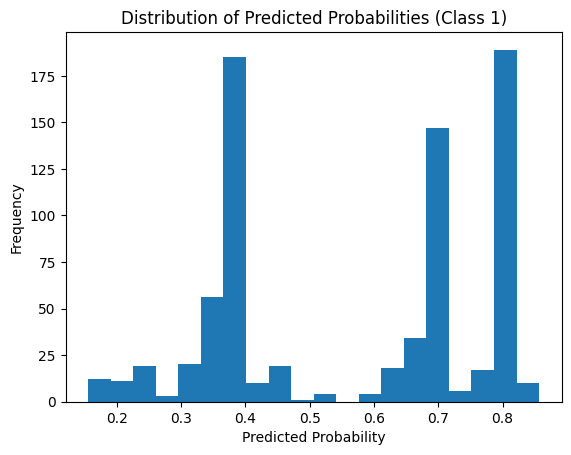

In [126]:
print(">= 0.95:", np.sum(unknown_probs >= 0.95))
print("<= 0.05:", np.sum(unknown_probs <= 0.05))
print("Between 0.4 and 0.6:", np.sum((unknown_probs > 0.4) & (unknown_probs < 0.6)))

plt.figure()
plt.hist(unknown_probs, bins=20)
plt.title("Distribution of Predicted Probabilities (Class 1)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()

### Saving predictions

In [127]:
pred_map = {1: "O1_Ogawa", 0: "O1_Inaba"}
unknown_results["Predicted_serotype"] = unknown_results["Predicted_Label"].map(pred_map)

unknown_results = unknown_results.rename(columns={"Probability_Class1": "Probability_Ogawa"})
unknown_final = unknown_results[["Sample_ID","Predicted_serotype","Probability_Ogawa"]].copy()
#unknown_final

In [128]:
len(unknown_final)

765

In [129]:
label_map = {1: "O1_Ogawa", 0: "O1_Inaba"}
labeled_df = pd.DataFrame({"Sample_ID": X_labeled.index,"Serotype": y_labeled.map(label_map)})
labeled_df

,Sample_ID,Serotype
Sample_ID,,
VC_0007,VC_0007,O1_Ogawa
VC_0014,VC_0014,O1_Ogawa
VC_0015,VC_0015,O1_Inaba
VC_0016,VC_0016,O1_Inaba
VC_0017,VC_0017,O1_Inaba
...,...,...
VC_0057,VC_0057,O1_Ogawa
VC_0058,VC_0058,O1_Ogawa
VC_0059,VC_0059,O1_Ogawa


In [130]:
combined_df = pd.concat([labeled_df, unknown_final],ignore_index=True)

In [131]:
unknown_final.to_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/2_serotype_predictions.csv")
combined_df.to_csv("/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/3_serotype_pred_combined.csv")

### Plots

#### ROC AUC

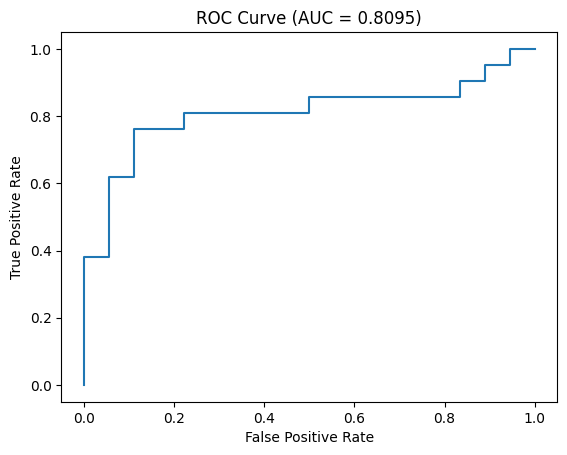

In [132]:
fpr, tpr, _ = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

#### Confusion matrix

Text(0.5, 1.0, 'Confusion Matrix')

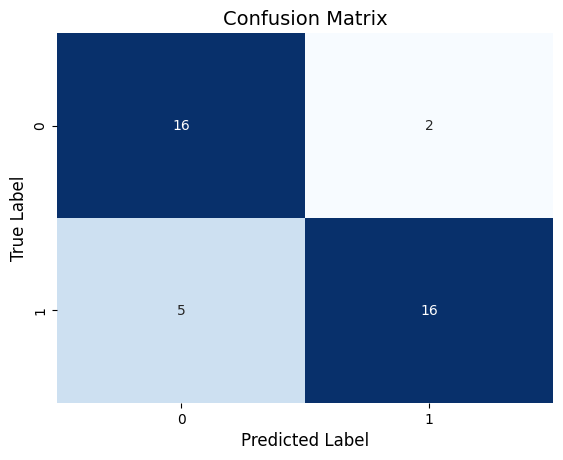

In [133]:
cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)

#### Feature importance

In [134]:
label_map = build_label_map(gpa_path)
out_file = "/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/blast_results_serotype.tsv"

Running BLAST for 4 hypothetical genes...
group_7888
  BEFORE: hypothetical protein (group_7888)
  AFTER : Transposase InsN for insertion sequence element IS911

group_883
  BEFORE: hypothetical protein (group_883)
  AFTER : (R)-mandelonitrile lyase

group_1443
  BEFORE: hypothetical protein (group_1443)
  AFTER : Uncharacterized protein ORF88



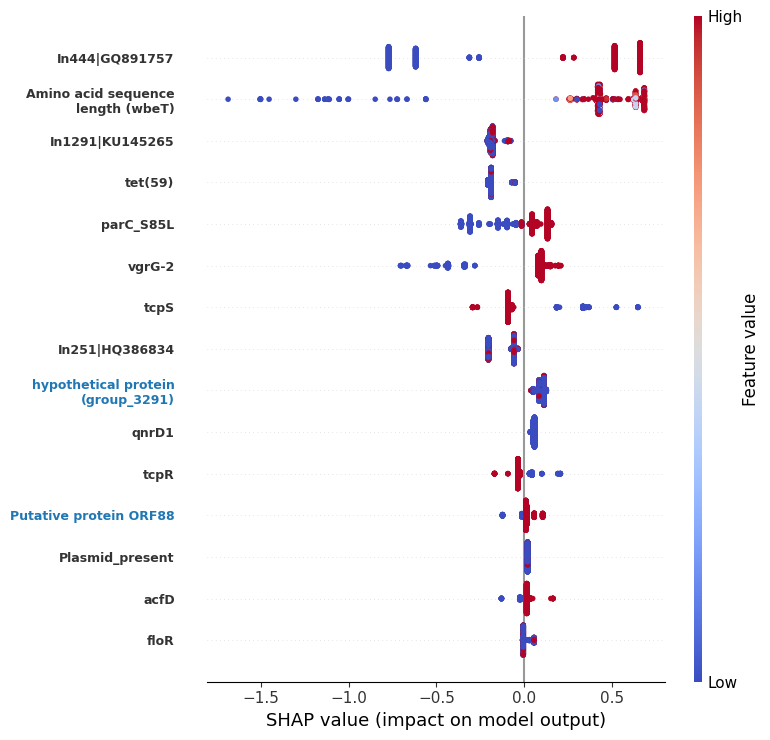

In [135]:
plot_shap_summary(model=final_model,X=X,
                  features=features,label_map=label_map,
                  level="serotype",
                  fasta_file=fasta_file,
                  blast_db=blast_db,
                  raw_features=oagc_features,
                  max_display=15,
                  save_path = "/media/dell/My Passport/vc_files_v_final/plots/2_st_shap.tif")

# Final serotypes

In [136]:
# predicted labels
serogroup_pred = pd.read_csv(
    '/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/3_supervised_ml/1_serogroup_files/3_serogroup_pred_combined.csv')
#serogroup_pred
serogroup_pred = serogroup_pred[['Sample_ID','Predicted_serogroup']]

serotype_pred = pd.read_csv("/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/3_supervised_ml/2_serotype_files/3_serotype_pred_combined.csv")
#serotype_pred
serotype_pred = serotype_pred[['Sample_ID','Predicted_serotype']]

final_df = pd.merge(serogroup_pred, serotype_pred, on='Sample_ID', how='outer')
#final_df

In [137]:
metadata = pd.read_csv("/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/1_data_curation/metadata_filtered.csv")
serotype_info = metadata[['Sample_ID','serogroup_serotype']]  # metadata labels (known)
#serotype_info 
final_df = pd.merge(serotype_info, final_df, on='Sample_ID', how='outer')
final_df['serogroup_serotype'].value_counts()

serogroup_serotype
unkwn           1455
non_O1           129
O1_Ogawa         106
O1_Inaba          88
O1_unkwn          87
O1_Hikoshima       1
Name: count, dtype: int64

In [138]:
final_df["all_serotypes"] = final_df["serogroup_serotype"] # metadata values (known)

final_df.loc[final_df["all_serotypes"] == "O1_unkwn", 
    "all_serotypes"] = final_df["Predicted_serotype"] # O1_unkwn with predicted serotype

final_df.loc[final_df["all_serotypes"] == 
    "unkwn", "all_serotypes"] = final_df["Predicted_serogroup"] # first unkwn with predicted serogroup
final_df.loc[final_df["all_serotypes"] == 
    "O1", "all_serotypes"] = final_df["Predicted_serotype"] # If it was predicted as O1 - then with predicted serotype column

In [139]:
#final_df
final_df['all_serotypes'].value_counts()

all_serotypes
non_O1          906
O1_Ogawa        535
O1_Inaba        424
O1_Hikoshima      1
Name: count, dtype: int64

In [140]:
final_df.to_csv('/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/serotypes_predicted.csv')

# Tree representation

In [141]:
final_df = pd.read_csv('/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/serotypes_predicted.csv')
#final_df = final_df[['Sample_ID','all_serotypes']]

In [142]:
print(final_df[final_df["all_serotypes"].isna()])

Empty DataFrame
Columns: [Unnamed: 0, Sample_ID, serogroup_serotype, Predicted_serogroup, Predicted_serotype, all_serotypes]
Index: []


In [143]:
final_df = final_df[['Sample_ID','all_serotypes']]
label_color_dict = {
    "O1_Inaba" : "#9FA1FF",
    "O1_Ogawa" : "#FCBAAD",
    "O1_Hikoshima" : "#F2320C",
    "non_O1" : '#4A4466'} 

serotype_itol = final_df[['Sample_ID','all_serotypes']].copy()
serotype_itol["Color"] = final_df["all_serotypes"].map(label_color_dict).fillna("#D3D3D3")

for _, row in serotype_itol.iterrows():
    print(f"{row['Sample_ID']}\t{row['Color']}\t{row['all_serotypes']}")

VC_0001	#4A4466	non_O1
VC_0002	#4A4466	non_O1
VC_0003	#4A4466	non_O1
VC_0004	#4A4466	non_O1
VC_0005	#4A4466	non_O1
VC_0006	#4A4466	non_O1
VC_0007	#FCBAAD	O1_Ogawa
VC_0008	#4A4466	non_O1
VC_0009	#4A4466	non_O1
VC_0010	#4A4466	non_O1
VC_0011	#4A4466	non_O1
VC_0012	#4A4466	non_O1
VC_0013	#4A4466	non_O1
VC_0014	#FCBAAD	O1_Ogawa
VC_0015	#9FA1FF	O1_Inaba
VC_0016	#9FA1FF	O1_Inaba
VC_0017	#9FA1FF	O1_Inaba
VC_0018	#4A4466	non_O1
VC_0019	#4A4466	non_O1
VC_0020	#9FA1FF	O1_Inaba
VC_0021	#9FA1FF	O1_Inaba
VC_0022	#9FA1FF	O1_Inaba
VC_0023	#9FA1FF	O1_Inaba
VC_0024	#9FA1FF	O1_Inaba
VC_0025	#9FA1FF	O1_Inaba
VC_0026	#9FA1FF	O1_Inaba
VC_0027	#4A4466	non_O1
VC_0028	#9FA1FF	O1_Inaba
VC_0029	#9FA1FF	O1_Inaba
VC_0030	#4A4466	non_O1
VC_0031	#9FA1FF	O1_Inaba
VC_0032	#9FA1FF	O1_Inaba
VC_0033	#9FA1FF	O1_Inaba
VC_0034	#9FA1FF	O1_Inaba
VC_0035	#9FA1FF	O1_Inaba
VC_0036	#9FA1FF	O1_Inaba
VC_0037	#9FA1FF	O1_Inaba
VC_0038	#9FA1FF	O1_Inaba
VC_0039	#9FA1FF	O1_Inaba
VC_0040	#9FA1FF	O1_Inaba
VC_0041	#9FA1FF	O1_Inaba
VC_0042

# Multipanel image

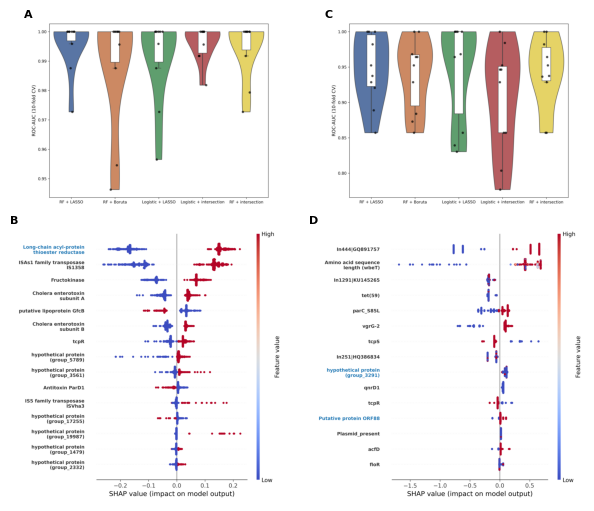

In [3]:
# Loading saved tif files
feat_sel_sg = mpimg.imread("/media/dell/My Passport/vc_files_v_final/plots/1_sg_class_ml.tif")
feat_sel_st = mpimg.imread("/media/dell/My Passport/vc_files_v_final/plots/1_st_class_ml.tif")
shap_sg = mpimg.imread("/media/dell/My Passport/vc_files_v_final/plots/2_sg_shap.tif")
shap_st = mpimg.imread("/media/dell/My Passport/vc_files_v_final/plots/2_st_shap.tif")

fig = plt.figure(figsize=(6, 5), constrained_layout=True)

gs = GridSpec(2, 2,figure=fig,height_ratios=[1.5, 2.2])

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])

# feature selection for serogroup
axA.imshow(feat_sel_sg)
axA.axis("off")
axA.text(-0.02, 1.02, "A",transform=axA.transAxes,fontsize=8,fontweight="bold")

# feature selection for serotype
axB.imshow(feat_sel_st)
axB.axis("off")
axB.text(-0.02, 1.02, "C",transform=axB.transAxes,fontsize=8,fontweight="bold")

# feature importance for serogroup
axC.imshow(shap_sg)
axC.axis("off")
axC.text(-0.02, 1.02, "B",transform=axC.transAxes,fontsize=8,fontweight="bold")

# feature importance for serotype
axD.imshow(shap_st)
axD.axis("off")
axD.text(-0.02, 1.02, "D",transform=axD.transAxes,fontsize=8,fontweight="bold")

plt.savefig("/media/dell/My Passport/vc_files_v_final/plots/final/pdf_files/2_ml_multipanel.pdf",bbox_inches="tight")
plt.savefig("/media/dell/My Passport/vc_files_v_final/plots/final/tif_files/2_ml_multipanel.tiff",dpi=300,bbox_inches="tight",pil_kwargs={"compression": "tiff_lzw"})
plt.show()

In [225]:
# consistent with previous results